# Ising formulations of many NP problems
<a id="ref-lucas"></a>
[Lucas 2014] Lucas, A. *Ising formulations of many NP problems*. 
Frontiers in Physics, 2 (2014). [arXiv:1302.5843](https://arxiv.org/abs/1302.5843)

# Imports



In [1]:
import numpy as np
import scipy
import math
import random

import itertools
from itertools import product # for generating all possible states of x

import time

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation # makes the animarion
from matplotlib.animation import PillowWriter #.gif writer

from IPython.display import HTML,display # display in nb

import networkx as nx # graphs
import osmnx as ox # OpenStreetMap
from geopy.geocoders import Nominatim # eircodes to positions
import pyproj # long,lat to utm

from numba import njit #optimization


# Spin glass annealing
Importing the code _spinglass.ipynb_ from 

In [2]:
def energy(s, J, h):
    # s is a flat 1D array of spins
    # J is (n, n) matrix
    # h is (n) vector
    return 0.5 * s @ J @ s - h @ s

@njit
def sweep_once(s, J, h, T, E):
    n=len(s)
    for _ in range(n):
        i = np.random.randint(n)
        
        dE = 2 * s[i] * (J[i] @s + h[i])        

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[i] *= -1
            E += dE

    return E

def sim_annealing(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy()


# Partitioning Problems
These partitioning problems are based off _spinglass.ipynb_  where we have a spin glass model.

$H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

 We will need to swap the general ising model build function `make_2d_ising(N,J_scalar,h_scalar)` to a function that has our problems ising structure. Building Q based off the energy cost function is our goal here.

## Number Partitioning 
Given a set of $N$ positive numbers $S=\{n_1,\cdots ,n_N\}$, is there a partition of numbers into two disjoint sets such that $R$ and $S-R$ have equal sums of their elements?

Our cost function will be,

$H=-A\left(\sum_i^Nn_is_i\right)^2=$

$\underbrace{-A\sum_{i=j}^Nn_i^2}_\text{constant}-2A\sum_{i<j}^Nn_in_js_is_j$

we can drop the constant in our optimization.

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

$J_{ij}=-An_in_j$

$h_i=0$

In [3]:
def make_partition_ising_slower(n,A=1.0):
    n = np.asarray(n, dtype=np.float64)
    N=len(n)
    J = np.zeros((N,N))
    
    for i in range(N):
        for j in range(i+1,N):
            J[i,j] = -A * n[i] * n[j]
            J[j,i] = J[i,j]
    
    h = np.zeros(N)
    
    return J, h
    
def make_partition_ising(n, A=1.0):
    n = np.asarray(n, dtype=np.float64)

    J = -2 * A * np.outer(n, n)
    np.fill_diagonal(J, 0.0)

    h = np.zeros(len(n))

    return J, h

This structure defines ouf Q interaction matrix.

In [4]:
numbers = np.array([3,1,1,2,2,1])

J, h = make_partition_ising(numbers)

temps, energies, spins = sim_annealing(
    J, h,
    T_start=10,
    T_end=0.01,
    alpha=0.99,
    sweeps_per_T=100
)

setA = numbers[spins == 1]
setB = numbers[spins == -1]

print("Set A:", setA, "sum =", np.sum(setA))
print("Set B:", setB, "sum =", np.sum(setB))
print("Difference =", abs(np.sum(setA) - np.sum(setB)))

Set A: [3 2] sum = 5
Set B: [1 1 2 1] sum = 5
Difference = 0


Defining a function for this problem

In [5]:
def run_partition_example(numbers,sweeps):
    print("Inputed numbers:", numbers)

    J, h = make_partition_ising(numbers)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    setA = numbers[spins == 1]
    setB = numbers[spins == -1]

    print("Set A:", setA, "sum =", np.sum(setA))
    print("Set B:", setB, "sum =", np.sum(setB))
    print("Difference =", abs(np.sum(setA) - np.sum(setB)))

We can try it for a random $n_i=rand$ for $S=\{n_1,\cdots ,n_N\}$

In [6]:
for _ in range(5):
    random_numbers = np.random.randint(1, 100, size=20)
    print(run_partition_example(random_numbers, 1000))

Inputed numbers: [85 42 51 71 28 53 76 74 30 97 71 51 76 20 44 35 23 81 71 59]
Set A: [42 51 28 74 97 51 76 20 35 23 71] sum = 568
Set B: [85 71 53 76 30 71 44 81 59] sum = 570
Difference = 2
None
Inputed numbers: [28 55 77 94  5  5 33 29 89 64 33 68 88 90 94 76 55  9 48 97]
Set A: [77 94  5 29 89 64 33 94 76  9] sum = 570
Set B: [28 55  5 33 68 88 90 55 48 97] sum = 567
Difference = 3
None
Inputed numbers: [ 8 43 13 13 34 28 27 13 40 14 91 49 75 51 10 81 14  6 86 26]
Set A: [ 8 34 13 14 49 51 10 81 14 86] sum = 360
Set B: [43 13 13 28 27 40 91 75  6 26] sum = 362
Difference = 2
None
Inputed numbers: [53 12 83 17  8 85 86 75 82 54 85 95 55 41 37 50 60 98 23 56]
Set A: [53 83 82 54 85 55 41 98 23] sum = 574
Set B: [12 17  8 85 86 75 95 37 50 60 56] sum = 581
Difference = 7
None
Inputed numbers: [31 30 13 42 13  3 15 24 95 30 32  6 97 95 56 96 68 28 29 54]
Set A: [31 30 13 15 24 32  6 97 95 56 29] sum = 428
Set B: [13 42  3 95 30 96 68 28 54] sum = 429
Difference = 1
None


It solves our problem to the best of its ability, minimising the distance between two sets.

## Graph Partitioning

Given some undirected graph $G(V,E)$, where $v\in v$ are vertices and $e\in E$ are edges, we take a graph with and even number of edges $N=|V|$. The optimisation problem, what is the partition of V into two subsets that minimises the number of edges connecting the two subsets?

$ H=H_A+H_B$

$=A\left(\sum_i^Ns_i\right)^2+B\sum_{(i,j)\in E}\frac{1-s_is_j}{2}$

$=\underbrace{AN} _{\text{constant}}+\underbrace{\frac{B|E|}{2}}_{\text{constant}}+2A\sum_{i>j}^ Ns_is_j -\frac{B}{2}\sum_{(i,j)\in E}  s_is_j$

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$. 

$J_{ij}=\begin{cases}
        -2A ~~~~~~~~~\text{if }~(i,j)\notin E\\
        -2A -\frac{B}{2}~~~\text{if }~(i,j)\in E
    \end{cases}$

$h_i=0$

There exists a constraint on $A$ and $B$,

$\frac{A}{B}\geq\frac{\min(2\Delta,N)}{8}$ where $\Delta=\text{degree of } G$

In [7]:
nodes = ['a', 'b', 'c', 'd']
#     idx 0    1    2    3
idx = {v: i for i, v in enumerate(nodes)}

print(nodes)
print(idx)

# idx swaps label and index of nodes in a graph

['a', 'b', 'c', 'd']
{'a': 0, 'b': 1, 'c': 2, 'd': 3}


In [8]:
def make_graph_partition(G, A, B):
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    
    J = -2.0 * A * np.ones((N, N))
    np.fill_diagonal(J, 0.0)
    
    #
    idx = {v:i for i,v in enumerate(nodes)}
    
    for u,v in G.edges():
        i, j = idx[u], idx[v]
        J[i,j] += B/2.0
        J[j,i] += B/2.0
    
    h = np.zeros(N)
    return J, h

def decode_partition_solution(G, s):
    nodes = list(G.nodes())
    
    setA = [nodes[i] for i in range(len(s)) if s[i] == 1]
    setB = [nodes[i] for i in range(len(s)) if s[i] == -1]
    
    cut_edges = [(u,v) for u,v in G.edges() if (u in setA) != (v in setA)]
    
    print ("Set A:", setA , "size =", len(setA))
    print ("Set B:", setB , "size =", len(setB))
    print ("Cut edges:", cut_edges , "size =", len(cut_edges))
    
    return setA, setB, cut_edges

def check_valid_AB(A,B,G):
    N=G.number_of_nodes()
    delta=max(d for _,d in G.degree()) # max degree of graph
    rhs=min(2*delta, N)/8 
    lhs= A / B
    valid = lhs >= rhs
    print(f"Max degree Δ={delta},  bound A/|B| >= {rhs:.3f}")
    print(f"Current A/|B| = {lhs:.3f}  {'valid' if valid else 'INVALID'}")
    
    return valid

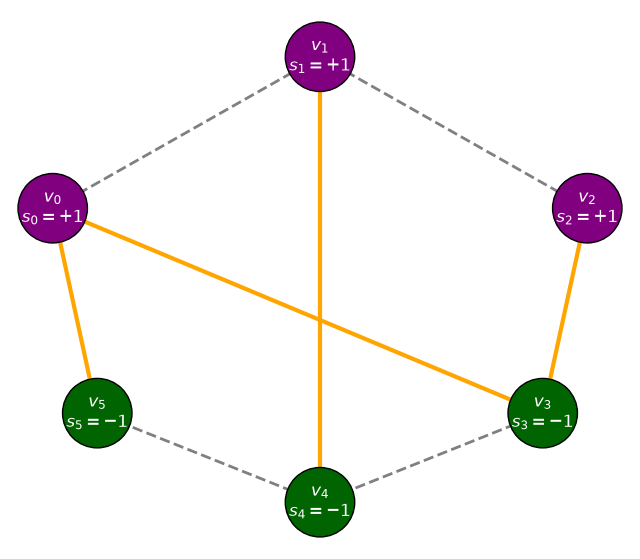

In [9]:
# Cycle graph C6 plus two connections
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

# positions for nodes in the graph for plotting to match my layout in Tikz
pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}

# worst spin configuration
spins = np.array([1, 1, 1, -1, -1, -1])

# Colour nodes
node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

# Separate cut and internal edges
cut_edges = []
internal_edges = []

for u, v in G.edges():
    if spins[u] != spins[v]:
        cut_edges.append((u, v))
    else:
        internal_edges.append((u, v))

plt.figure(figsize=(8,7))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=2500,
    edgecolors='black'
)

# Labels
labels = {i: f"$v_{i}$\n$s_{{{i}}}={spins[i]:+d}$" for i in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_color='white')

# Internal edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=internal_edges,
    edge_color='gray',
    style='dashed',
    width=2
)

# Cut edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=cut_edges,
    edge_color='orange',
    width=3
)

plt.axis('off')
plt.axis('equal')
plt.show()

We can make a plotting function without defining postions using `pos = nx.spring_layout(G, seed=13)` with a seed for reproducibility. Instead of inputing

`pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}`

We'll also make a spin-less/empty node graph function

In [ ]:
def draw_empty_graph(G):
    pos = nx.spring_layout(G, seed=13)  

    n = G.number_of_nodes()
    
    node_colors = 'purple'

    all_edges = []

    for u, v in G.edges():
        all_edges.append((u, v))

    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {i: f"$v_{ {i} }$" for i in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=all_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    plt.axis('off')
    plt.axis('equal')
    
    #plt.save
    #plt.savefig("/home/cian/Documents/college/SURE/git/QUBO/example-problems/orginal-graph-partitioning.pdf")
    plt.show()

And one with the cut edges defined once we input a spin.

In [ ]:
def draw_graph_partition(G, spins):
    pos = nx.spring_layout(G, seed=13)  
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    n = G.number_of_nodes()
    
    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {}

    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{{i}}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=internal_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    # Cut edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=cut_edges,
        edge_color='orange',
        width=3
    )

    plt.axis('off')
    plt.axis('equal')
    
    #plt.savefig("/home/cian/Documents/college/SURE/git/QUBO/example-problems/annealed-graph-partitioning.pdf")


    plt.show()

In [12]:
def run_partition_graph_example(G, A, B, sweeps):
    print("Inputed graph:")
    draw_empty_graph(G)
    
    print(f"A={A}, B={B}")
    check_valid_AB(A, B, G)

    J, h = make_graph_partition(G, A, B)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    #setA, setB, cut_edges = decode_partition_solution(G, spins)
    
    draw_graph_partition(G, spins)

Inputed graph:


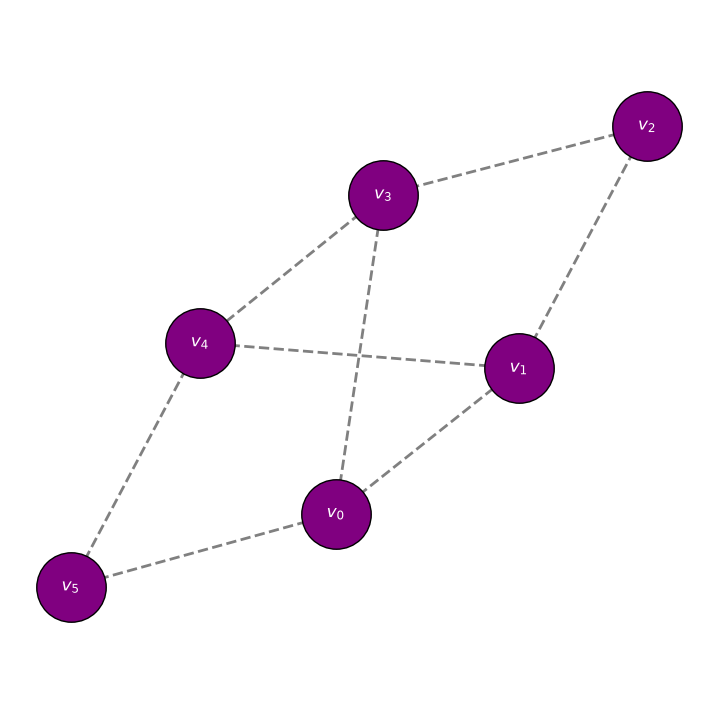

A=4, B=2
Max degree Δ=3,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


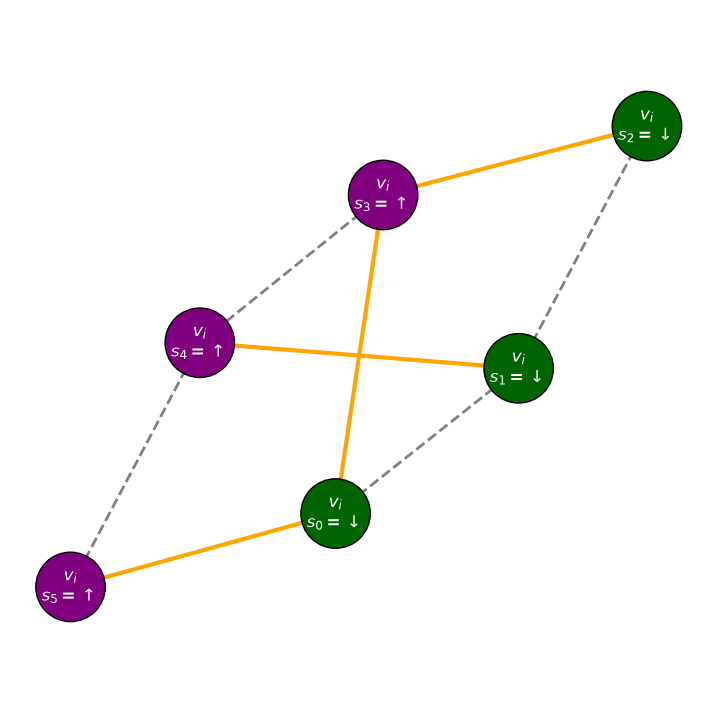

In [13]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

run_partition_graph_example(G, A=4, B=2, sweeps=1000)

That is solving the problem to minimise the cut edes, now we can try it with random $G(E,V)$
#### Random

In [75]:
def make_random_graph(lower,upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")
    
    return G

def run_random_partition_graph_example(lower, upper):
    make_random_graph(lower,upper)
    run_partition_graph_example(G, A=4, B=2, sweeps=1000)

n = 24
Added 7 extra edges
Inputed graph:


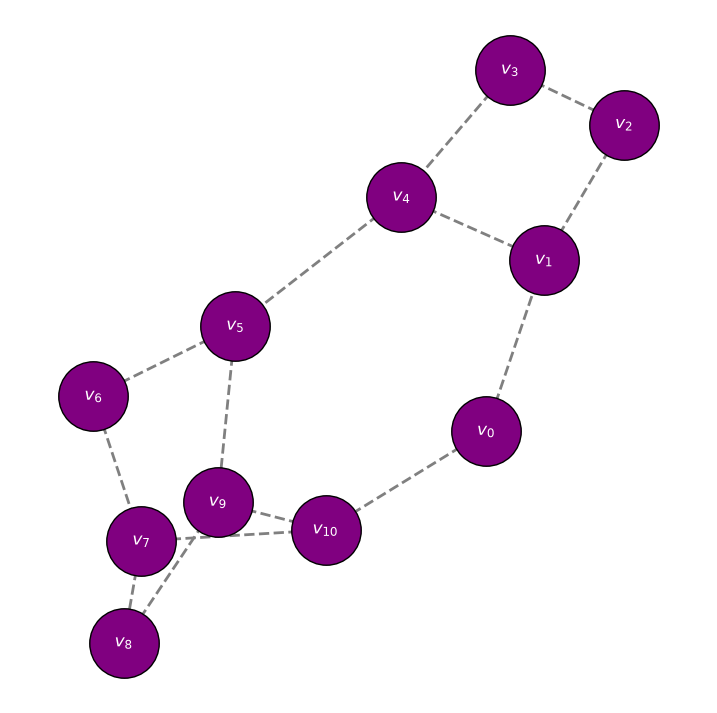

A=4, B=2
Max degree Δ=3,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


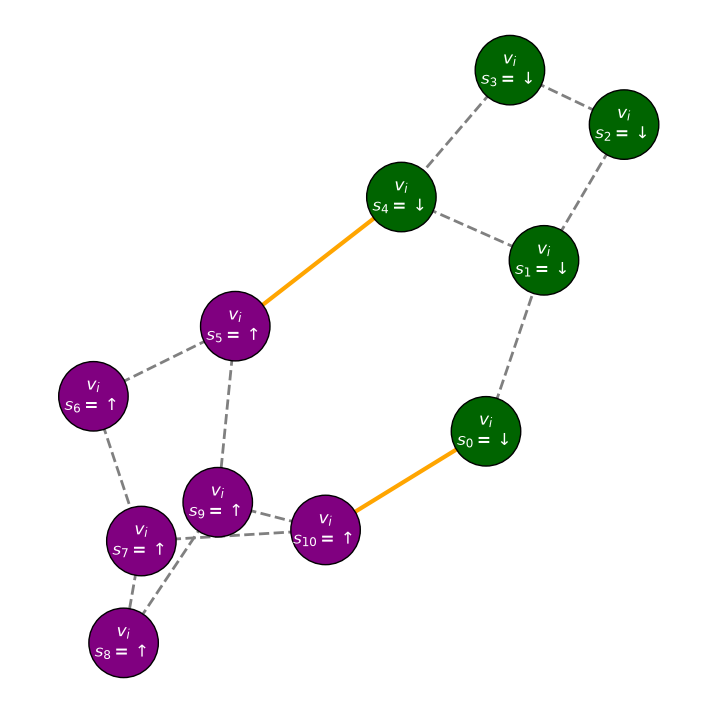

In [78]:
run_random_partition_graph_example(20, 30)

#### Animation

I think it'd be fun to plot the annealing process. We need to save the spin history in the annealing, then update our spins diagrams.

Redefining the annealing,



In [16]:
def sim_annealing_animation(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    history = []
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        history.append(s.copy())
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy(), history

In [17]:
def update(frame):
    
    ax.clear()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    
    spins = history[frame]
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=1900,
        edgecolors='black',
        ax=ax
    )
    
    # Labels
    labels = {}
    
    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_color="white",
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=internal_edges,
        edge_color="gray",
        style="dashed",
        width=2,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cut_edges,
        edge_color="orange",
        width=3,
        ax=ax,
    )
    
    ax.set_title(
        f"Step {frame} | "
        f"T = {temps[frame]:.3f} | "
        f"E = {energies[frame]:.2f}",
        fontsize=16
    )
    
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    

In [18]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

def run_partition_graph_animation(G):
    pos = nx.spring_layout(G, seed=13)

    # fix the axis limits to avoid rescaling during the animation
    x_values = [p[0] for p in pos.values()]
    y_values = [p[1] for p in pos.values()]

    margin = 0.5

    xlim = (min(x_values)-margin, max(x_values)+margin)
    ylim = (min(y_values)-margin, max(y_values)+margin)

    n = G.number_of_nodes()
    size = max(9, 0.8 * n)

    fig, ax = plt.subplots(figsize=(size, size))

    J, h = make_graph_partition(G, A=4, B=4)
    temps, energies, spins, history = sim_annealing_animation(
        J,
        h,
        T_start=10,
        T_end=0.1,
        alpha=0.99,
        sweeps_per_T=1000
        )

    history = history[::2]  # downsample the history for faster animation
    energies = energies[::2]  # downsample the energies for faster animation
    temps = temps[::2]  # downsample the temperatures for faster animation
    spins = spins[::2]  # downsample the spins for faster animation

    def update(frame):
        
        ax.clear()
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        
        spins = history[frame]
        
        # Colour nodes
        node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

        # Separate cut and internal edges
        cut_edges = []
        internal_edges = []

        for u, v in G.edges():
            if spins[u] != spins[v]:
                cut_edges.append((u, v))
            else:
                internal_edges.append((u, v))

        # Nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color=node_colors,
            node_size=1900,
            edgecolors='black',
            ax=ax
        )
        
        # Labels
        labels = {}
        
        for i in G.nodes:
            arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
            labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
        
        nx.draw_networkx_labels(
            G,
            pos,
            labels,
            font_color="white",
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=internal_edges,
            edge_color="gray",
            style="dashed",
            width=2,
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=cut_edges,
            edge_color="orange",
            width=3,
            ax=ax,
        )
        
        ax.set_title(
            f"Step {frame} | "
            f"T = {temps[frame]:.3f} | "
            f"E = {energies[frame]:.2f}",
            fontsize=16
        )
        
        ax.set_axis_off()
        ax.set_aspect("equal")
    
    
    
    animation = FuncAnimation(fig, update, frames=len(history), interval=500, repeat=False)
    
    return animation

In [19]:
# display the animation in the notebook
# display(HTML(animation.to_jshtml()))

# download the animation as a GIF
'''
animation.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)
'''

'\nanimation.save(\n    "annealing.gif",\n    writer=PillowWriter(fps=10)\n)\n'

In [20]:
def run_random_partition_graph_animation(lower, upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")

    anim_random = run_partition_graph_animation(G)
    
    return anim_random

In [21]:
'''anim = run_random_partition_graph_animation(10, 35)
anim.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)'''

'anim = run_random_partition_graph_animation(10, 35)\nanim.save(\n    "annealing.gif",\n    writer=PillowWriter(fps=10)\n)'

These seem to work, they're a nice display of the annealing process.

# QUBO annealing
Importing the solving functions from`QUBO-anneal.pynb`, this is less optimised than my ising model code. All we've done is redefine the energy function and sweeping functions.

In [160]:
@njit
def energy_QUBO(x, Q):
    return x @ Q @ x

@njit
def sweep_once_QUBO(x, Q, T, E):
    N = len(x)
    for _ in range(N):
        i = np.random.randint(N) 

        old_bit = x[i]
        x[i] = 1 - x[i]  # Flip the binary spin (0 to 1 or 1 to 0)
        
        # Calculate the change in energy if we flip spin i
        new_E = energy_QUBO(x, Q)
        delta_E = new_E - E
        
        # Metropolis criterion
        if delta_E < 0 or np.random.rand() < np.exp(-delta_E / T):
            E = new_E  # Accept the new configuration
        else:
            x[i] = old_bit  # Revert the flip if not accepted  
            
    return E

def sim_annealing_QUBO(Q, T_start, T_end, alpha, sweeps_per_T):
    n = Q.shape[0]
    x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)

    E = energy_QUBO(x, Q)

    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once_QUBO(x, Q, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), x.copy()

lets remove`new_E = energy_QUBO(x, Q)` since it computes the energy new everytime and only recompute the terms involving the flip.


In [161]:
@njit
def delta_energy(x, Q, i):
    s = 0.0
    N = len(x)

    for j in range(N):
        if j != i:
            s += Q[i, j] * x[j]

    if x[i] == 0:
        # 0 -> 1
        return Q[i, i] + 2.0 * s
    else:
        # 1 -> 0
        return -(Q[i, i] + 2.0 * s)

@njit
def sweep_once_QUBO(x, Q, T, E):

    N = len(x)

    for _ in range(N):

        i = np.random.randint(N)

        dE = delta_energy(x, Q, i)

        if dE < 0 or np.random.rand() < np.exp(-dE / T):

            x[i] = 1 - x[i]
            E += dE

    return E

We also have a small brute force checker to compare to our annealing results, I believe its only feasable for 2-4 Qs.

In [162]:
def brute_force_qubo(Q):
    n = Q.shape[0]

    best_energy = np.inf # set  to infiniy  
    best_x = None

    for x in product([0, 1], repeat=n): #produce generate all possible binary configurations of length n
        x = np.array(x, dtype=np.int8)
        E = x @ Q @ x

        if E < best_energy:
            best_energy = E
            best_x = x.copy()

    return best_energy, best_x

added temp estimater from rocket control


In [163]:
def estimate_temperature_range(Q, n_samples=100, hot_accept_prob=0.8, cold_accept_prob=1e-3):
    n = Q.shape[0]
    all_dEs = []

    for _ in range(n_samples):
        x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)
        for i in range(n):
            dE = delta_energy(x, Q, i)
            all_dEs.append(abs(dE))

    all_dEs = np.array(all_dEs)
    all_dEs = all_dEs[all_dEs > 0]   # ignore zero-moves, they don't inform temperature scale

    dE_typical = np.percentile(all_dEs, 50)   # median dE, for T_start
    dE_small   = np.percentile(all_dEs, 5)    # a small dE, for T_end

    T_start = -dE_typical / np.log(hot_accept_prob)
    T_end   = -dE_small / np.log(cold_accept_prob)

    return T_start, T_end, all_dEs

# qubo anneal converge

In [164]:
def sim_annealing_QUBO_converge(Q, alpha, window=50, tol=1e-3, max_sweeps=5000,verbose=False):
    
    T_start, T_end, _ = estimate_temperature_range(Q,
        n_samples=20, hot_accept_prob=0.5, cold_accept_prob=1e-3)
    '''
    if verbose==True:
        print(f"Starting temp: {T_start:.2f}\nEnding temp: {T_end:.2f}")
        estimate_runtime_converge_fast(Q, T_start, T_end, alpha, window, tol,
            n_reads,n_probe_early=10, n_probe_late=1, max_sweeps=5000)
     '''       
    n = Q.shape[0]
    x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)

    E = energy_QUBO(x, Q)

    temps = []
    energies = []
    sweeps_used = []


    T = T_start
    
    while T > T_end:
        E, s_done = sweep_until_converged(x, Q, T, E, window, tol, max_sweeps)

        #test
        #E_true = energy_QUBO(x,Q)
        #print(T, E-E_true)

        temps.append(T)
        energies.append(E)
        sweeps_used.append(s_done)
        
        T *= alpha
    
    return np.array(temps), np.array(energies), x.copy()

@njit
def sweep_until_converged(x, Q, T, E, window=50, tol=1e-3, max_sweeps=5000):
    recent_energies = np.zeros(window)
    sweeps_done = 0
    for s in range(max_sweeps):
        E = sweep_once_QUBO(x, Q, T, E)
        recent_energies[s % window] = E
        sweeps_done += 1
        if s >= window:
            spread = recent_energies.max() - recent_energies.min()
            if spread < tol * abs(E):
                break
    return E, sweeps_done

# Binary Integer Linear Programming (BILP)

This class of problems is the next jump, we define the problem.

We have N binary variables $\vec x\in\{0,1\}^N$ which we want to arange into a vector $\vec x$ such that we maximise $\vec c \cdot \vec x$, given the restraint $S \vec x = \vec b$.

Where $S$ is a $m\times N$ matrix and $\vec b \in$ is a vector with m components.



Now taking a classic ILP problem is defined like,

$\underset{x,y \in \mathbb{Z}}{\text{maximize}} \quad  y$
subject to 
$\quad -x +y \leq 1, 3x + 2y \leq 12, 2x + 3y \leq 12, x,y \ge 0$


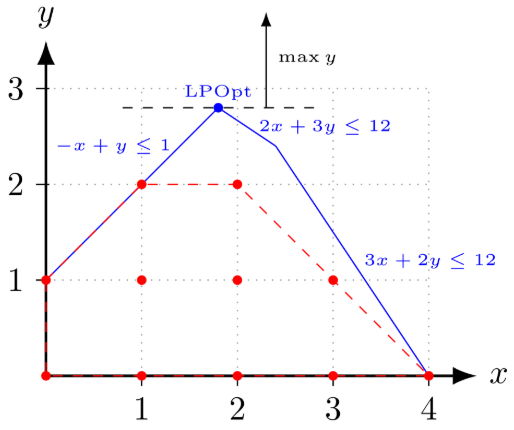

This is is a nice way of visulising our solution, however for our binary version there is no interior.

Now take some vector $\vec x=\begin{pmatrix}x_1\\x_2\\x_3\end{pmatrix}$ 

where $x_i\in\{0,1\}$ so our solutions are a cube with the corners being the solutions. So for N binary variables $\vec x\in\{0,1\}^N$ we have a  ***N*** *hyper-cube* for our solutions with no interior, so the classic ILP diagrams don't really help to visualise.


***Back to QUBO***

Now, we swap from ising formulation of $s=\begin{cases}1\\-1\end{cases}$ into a binary representation $x=\begin{cases}0\\1\end{cases}$

This can be done with the transformation, $x_i\rightarrow \frac{1+s_i}{2}$

Now like last time we will have two components to $H=H_A+H_B$

$H_A=A\sum_{j=1}^m\left(b_j-\sum_{i=1}^N S_{ji}x_i\right)^2$ this will enforce $S \vec x = \vec b$

&

$H_B = -B\sum_{i=1}^Nc_ix_i$ which will maximise $\vec c \cdot \vec x$


There exists conditions on $A$ and $B$ where $\frac{A}{B}\gtrsim N$

$H_A=\sum_{i=1}^N~\underbrace{A\sum_{j=1}^m(S_{ji}^2-2b_jS_{ji})}_{h_i}x_i+ \sum_{i<k}^N~\underbrace{2A\sum_{j=1}^mS_{ji}S_{jk}}_{J_{ij}}x_ix_k$

$H_B =\sum_{i=1}^N\underbrace{-Bc_i}_{h_i}x_i$

$Q_{ii}=A\sum_{j=1}^m(S_{ji}^2-2b_jS_{ji}) -Bc_i$

and

$Q_{ij}=2A\sum_{j=1}^mS_{ji}S_{jk}$

here we've swapped to $Q_{ij}$ instead of $J_{ij}$ since we have binary inputs rather than spins.

In [25]:
def make_BILP(S,b,c, A, B):
    # S is  mxn matrix of coefficients for constraints
    # b is m vector of constants for constraints
    # c is n vector of coefficients for the objective function
    
    m, N = S.shape
    Q = np.zeros((N, N))
    
    #diagonal terms  
    for i in range(N):
        Q[i,i] += A * np.sum(S[:,i]**2 - 2*b*S[:,i])  - B * c[i]
    
    # off-diagonal terms
    for i in range(N):
        for j in range(i+1, N):
            Q[i,j] += 2 * A * np.sum(S[:,i] * S[:,j])
            Q[j,i] = Q[i,j]
            
    return Q

def read_BILP(x, c, S, b, verbose):
    # x is a binary vector of length N
    # c is a vector of length N
    # S is a mxN matrix of coefficients for constraints
    # b is a vector of length m

    objective_value = c @ x
    constraint_values = S @ x
    residuals = constraint_values - b
    feasible = np.allclose(residuals, 0)
   
    print(f"x = {x.astype(int)}")
    
    if verbose:
    
        print(f"Objective value c·x = {objective_value}")
        #print(f"Constraint values Sx = {constraint_values}")
        print(f"Residuals Sx - b = {residuals}  (should be 0)")
        print(f"Feasible: {feasible}")

    return objective_value, constraint_values, residuals

In [26]:
def compare_brute_force_and_annealing(Q, S, b, c):
    Q = make_BILP(S, b, c, A, B)
    print("Q =\n", Q)
    # Brute force verify
    brute_E, brute_x = brute_force_qubo(Q)
    print("\nBrute force solution:")
    read_BILP(brute_x, c, S, b, False)
    #print(f"Brute force energy: {brute_E}")

    # Simulated annealing
    temps, energies, x_anneal = sim_annealing_QUBO(
        Q, 
        T_start=10.0, 
        T_end=0.01,
        alpha=0.95, 
        sweeps_per_T=1000
    )
    
    print("\nSimulated annealing solution:")
    read_BILP(x_anneal, c, S, b, False)
    #print(f"Annealing energy: {w}")
    
    def_x = brute_x - x_anneal
    same = np.allclose(def_x, 0)
    print(f"\nThe brute force and annealing are the same: {same}")

In [28]:
S = np.array([[1, 1, 1]], dtype=float)   # x1 + x2 + x3 = 1
b = np.array([1,0])
c = np.array([3.0, 1.0, 2.0])           # maximise 3x1 + x2 + 2x3

A=2.0
B=1.0

Q= make_BILP(S,b,c, A, B)
compare_brute_force_and_annealing(Q, S, b, c)


Q =
 [[-3.  4.  4.]
 [ 4. -1.  4.]
 [ 4.  4. -2.]]

Brute force solution:
x = [1 0 0]

Simulated annealing solution:
x = [1 0 0]

The brute force and annealing are the same: True


In [29]:
def random_BILP(m, N, seed=None,repeat=3):
    # instead of np.random reproducable
    rng = np.random.default_rng(seed)

    # Random feasible binary solution
    x_true = rng.integers(0, 2, size=N)
    
    print("x true", x_true)
    
    # Random constraint matrix
    S = rng.integers(-2, 3, size=(m, N)).astype(float)

    # Compute b so x_true is feasible
    b = S @ x_true

    # Random objective
    c = rng.integers(-5, 6, size=N).astype(float)

    A = 10 * np.sum(np.abs(c)) / np.min(np.sum(np.abs(S), axis=1))
    B = 1

    Q = make_BILP(S, b, c, A=A, B=B)
    
    print("Our Q matrix:")
    print (Q)
    
    print("x_true:", x_true)
    print("Feasible?", np.allclose(S @ x_true, b))
    print("Objective:", c @ x_true)
    
    for i in range(repeat):
        temps, energies, x_anneal = sim_annealing_QUBO(
            Q, 
            T_start=20.0, 
            T_end=1e-4,
            alpha=0.99, 
            sweeps_per_T=sweeps
        )
        
        print("\nSimulated annealing solution:", {i+1})
        read_BILP(x_anneal, c, S, b, True)
        #print("x:", x_anneal[:N])
        #print("Constraint residual:", S @ x_anneal[:N] - b)
        print("Objective:", c @ x_anneal[:N])

'''
for j in range(2,4,4):
    print("\n===== N =", j, "=====")
    sweeps = 2000 * j
    random_BILP(j, j, seed=42)
'''

'\nfor j in range(2,4,4):\n    print("\n===== N =", j, "=====")\n    sweeps = 2000 * j\n    random_BILP(j, j, seed=42)\n'

This last randomisation doesn't work, I believe its due to the values of $A$ and $B$, currently 

`A = 10 * np.sum(np.abs(c)) / np.min(np.sum(np.abs(S), axis=1))` `B=1`

doesn't seem to work.

We're going to move on cause BILP doesn't offer much more to our end goals.

# Graph Colouring

Lets take another undirected graph $G(V,E)$ and $n$ colours. Can we colour each vertex such that no edge connects vertices of the same colour? This is a generaliseation of the famous how many colours are needed to colour a map such that no two countries of the same colour share a border, ($n\geq 4$).

<a id="ref-appel1"></a>
[Appel and Haken 1977a] Appel, K. and Haken, W. *Every planar map is four colorable. I. Discharging*. Illinois Journal of Mathematics, **21**, 429–490 (1977).

<a id="ref-appel2"></a>
[Appel et al. 1977b] Appel, K., Haken, W., and Koch, J. *Every planar map is four colorable. II. Reducibility*. Illinois Journal of Mathematics, **21**, 491–567 (1977).

We introduce two index binary variables $x_{v,i}$ which will be one if vertex $v\in V$ has colour $i$ or its $0$.

We build a similar idea to previous examples with,

$H_{A,1}= A \sum_v\left(1-\sum_{i=1}^nx_{v,i}\right)^2$ 

which enforces that each index has one colour, penalising otherwise.

Then, 
$H_{A,2}= A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

adds a penalty for one colour $i$ connecting two vertices $u$ and $v$.

$H=A \sum_v\left(1-\sum_{i=1}^nx_{v,i}\right)^2 +A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

Now expanding our our square to read off our $Q$ matrix,

$H_{A,1}A=\sum_v \left(1 - \sum_i x_{v,i}\right)^2 
= A\sum_v\left(\underbrace{1}_{\text{drop}} - \sum_i x_{v,i} + \left(\sum_i x_{v,i}\right)^2\right)$

$= A\sum_v\left( - \sum_i x_{v,i} + 2\sum_{i<j} x_{v,i}x_{v,j}\right)$

and then $H_{A,2}$ is already quadratic,
$A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$



$H=A\sum_v\left(- \sum_i x_{v,i} + 2\sum_{i<j} x_{v,i}x_{v,j}\right) +A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

We need to flatten the indices out $(v,i)\rightarrow k=v\cdot n +i$, then we adjust our entries

In [30]:
def idx(v, i, n):
    return v * n + i    

def build_graph_colour(G,n_colours, A=1.0):
    
    N = G.number_of_nodes()
    n = n_colours
    
    nodes = list(G.nodes())
    node_idx = {v: i for i, v in enumerate(nodes)}
 
    Q = np.zeros((N * n, N * n))
    
    for v in range(N):
        for i in range(n):
        # diagonal: -A for every (v,i)
            Q[idx(v,i,n), idx(v,i,n)] -= A
        
        for i in range(n):
           for j in range(i+1,n):
            # same vertex, different colours: +2A
                Q[idx(v,i,n), idx(v,j,n)] += 2*A    
                
    for u,v in G.edges():
        u_idx = node_idx[u]
        v_idx = node_idx[v]
        
        for i in range(n):
        # edge conflict, same colour: +A
            Q[idx(u_idx,i,n), idx(v_idx,i,n)] += A
            Q[idx(v_idx,i,n), idx(u_idx,i,n)] += A
            
    return Q

def read_graph_colour(G, x, n_colours):
    nodes = list(G.nodes())
    N = len(nodes)
    n = n_colours
    
    colouring = {}
    valid = True

    # check multiple coloura
    for v in range(N):
        colours_assigned = [i for i in range(n) if x[idx(v,i,n)] == 1]
        if len(colours_assigned) != 1:
            print(f"vertex {nodes[v]}: invalid assignment {colours_assigned}")
            valid = False
        else:
            colouring[nodes[v]] = colours_assigned[0] # stores the colour
            
    # check edges
    conflicts = [(u,v) for u,v in G.edges() if colouring.get(u) == colouring.get(v)]
    

    print(f"Colouring: {colouring}")
    print(f"Conflicts: {conflicts}")
    print(f"Valid: {valid and len(conflicts) == 0}")
    return colouring , valid    

In [31]:
G = nx.cycle_graph(4)   # 4-cycle needs 2 colours
n_colours = 2

Q = build_graph_colour(G, n_colours, A=1.0)
best_E, best_x = brute_force_qubo(Q)

read_graph_colour(G, best_x, n_colours)

Colouring: {0: 1, 1: 0, 2: 1, 3: 0}
Conflicts: []
Valid: True


({0: 1, 1: 0, 2: 1, 3: 0}, True)

In [80]:
def plot_graph_colouring(G, colouring, valid, energy):

    if not valid:
        print("Cannot plot: colouring is invalid.")
        return

    palette = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
        "tab:olive",
        "tab:cyan",
    ]

    node_colours = [palette[colouring[v]] for v in G.nodes()]

    pos = nx.spring_layout(G, seed=1)

    plt.figure(figsize=(5,5))

    nx.draw_networkx_edges(G, pos, width=2)
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colours,
        node_size=800,
        edgecolors="black",
    )
    nx.draw_networkx_labels(G, pos)

    plt.title(f"Graph colouring\nEnergy = {energy}")
    plt.axis("off")
    plt.savefig("/home/cian/Documents/college/SURE/git/QUBO/example-problems/graph-colour.pdf")
    
    plt.show()

n = 11
Added 3 extra edges
We have 1 colours.
vertex 1: invalid assignment []
vertex 3: invalid assignment []
vertex 5: invalid assignment []
vertex 7: invalid assignment []
vertex 9: invalid assignment []
vertex 10: invalid assignment []
Colouring: {0: 0, 2: 0, 4: 0, 6: 0, 8: 0}
Conflicts: [(1, 5), (3, 9), (9, 10)]
Valid: False
We have 2 colours.
vertex 2: invalid assignment []
vertex 9: invalid assignment []
Colouring: {0: 0, 1: 1, 3: 0, 4: 1, 5: 0, 6: 1, 7: 0, 8: 1, 10: 1}
Conflicts: []
Valid: False
We have 3 colours.
Colouring: {0: 2, 1: 0, 2: 2, 3: 1, 4: 2, 5: 1, 6: 2, 7: 1, 8: 2, 9: 0, 10: 1}
Conflicts: []
Valid: True


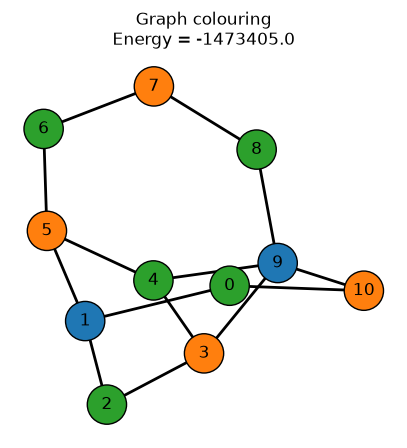

In [81]:
G = make_random_graph(9, 14)

valid = False
n_colours = 1

while not valid:

    print(f"We have {n_colours} colours.")

    Q = build_graph_colour(G, n_colours, A=1.0)

    temps, energies, spins = sim_annealing_QUBO(
        Q,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=1000,
    )

    best_x = spins
    best_E = energies[-1]

    colouring, valid = read_graph_colour(
        G,
        best_x,
        n_colours,
    )

    if not valid:
        n_colours += 1

plot_graph_colouring(G, colouring, valid, best_E)

# Hamiltonian Cycle/Path

 This is a generalisation of the famous *Seven Bridges of Konigsberg* which asked could you make it around the 7 bridges of the ciry without crossing the same bridge twice. Many mathmaticians like Euler attempted this,

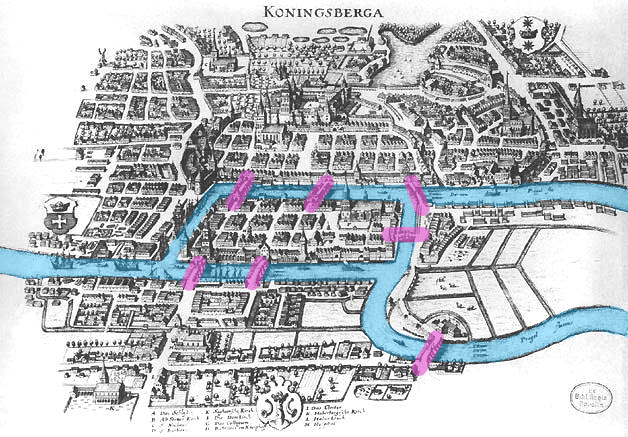

The Hamiltonian Path problem generalises this for some graph, $G(E,V)$ and $V=|N|$ (directed or undirected), can we start at one node and vist every node in the graph without returning to any node twice? If we enforce returning to the same point this becomes the Hamiltonian Cycle problem.


Now we label the vertices $v\in V$, $(1,2,\cdots,N)$, and the edges $(uv)\in E$ 

$\left[   (uv) \text{ directed order mattes, we can extend to undirected by adding} (vu) \text{whenever }(uv) \text{ is added to } E  \right]$ 

Our binary bits are $x_{v,i}$ where $v\in V$ is our vertex and $i$ is the order of the path/cycle. Our energy function will have three componets, $H=H_1+H_2+H_3$ , and will look similar to previous functions we've looked at.

Now $H_1$ will enforce that every vertice can only appear once in path/cycle,

$H_{1}= A \sum_{v=1}^n\left(1-\sum_{j=1}^Nx_{v,j}\right)^2$ 

$= A\sum_{v=1}^n\left(\underbrace{1}_{\text{drop}} - \sum_i^N x_{v,j} + \left(\sum_i^N x_{v,j}\right)^2\right)$

$= A\sum_{v=1}^n\left( - \sum_i^N x_{v,j} + 2\sum_{i<j}^N x_{v,i}x_{v,j}\right)$

Next, $H_2$ will enforce that there must be a $j^\text{th}$ node in the cycle/path for each $j$. 

$H_2=A \sum_{j=1}^N\left(1-\sum_{v=1}^nx_{v,j}\right)^2$

$H_2
=A\sum_{j=1}^{N}\left(\underbrace{1}_{\text{drop}}-2\sum_{v=1}^{n}x_{v,j}+\left(\sum_{v=1}^{n}x_{v,j} \right)^2\right)$

$=A\sum_{j=1}^{N}\left(-\sum_{v=1}^{n}x_{v,j}+2\sum_{u<v}^nx_{u,j}x_{v,j}\right)$

Finally, $H_3$ will need to penalise edges if we take $x_{u,j}$ and $x_{v,j+1}$ which are both one then we need to penalise this if $(u,v)\notin E$

$H_3=A\sum_{(uv)\notin E}\sum_{j=1}^N x_{u,j}x_{v,j+1}$

Combing this we get

$H_A=H_1+H_2+H_3$

$=A\sum_{v=1}^n\left( - \sum_i^N x_{v,j}\\ + 2\sum_{i<j}^N x_{v,i}x_{v,j}\right)\\
~~ + A\sum_{j=1}^{N}\left(-\sum_{v=1}^{n}x_{v,j}+2\sum_{u<v}^nx_{u,j}x_{v,j}\right)\\
~~ + A\sum_{(uv)\notin E}\sum_{j=1}^N x_{u,j}x_{v,j+1}$



In [34]:
def idx(v, j, N):
    return v * N + j

def build_hamiltonian_cycle(G,A):
    N = G.number_of_nodes()
    Q = np.zeros((N*N, N*N))

    #nodes = list(G.nodes())
    #node_idx = {v: j for j, v in enumerate(nodes)}
    for v in range(N):
        # diagonal
        for j in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for j1 in range(N):
            for j2 in range(j1+1, N):
                Q[idx(v,j1,N), idx(v,j2,N)] += 2*A
                Q[idx(v,j2,N), idx(v,j1,N)] += 2*A
                
    for j in range(N):

        # diagonal
        for v in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for u in range(N):
            for v in range(u+1, N):
                Q[idx(u,j,N), idx(v,j,N)] += 2*A
                Q[idx(v,j,N), idx(u,j,N)] += 2*A
                
    for u in range(N):
        for v in range(N):

            if u == v:
                continue

            if not G.has_edge(u, v):

                for j in range(N):

                    jp = (j + 1) % N      # wrap around for Hamiltonian cycle

                    Q[idx(u,j,N), idx(v,jp,N)] += A
                    Q[idx(v,jp,N), idx(u,j,N)] += A
    return Q


def read_hamiltonian_cycle(G,x):

    N = G.number_of_nodes()

    cycle = [None] * N
    valid = True
    
    # each vertex appears once
    for v in range(N):

        positions = [j for j in range(N) if x[idx(v, j, N)] == 1]

        if len(positions) != 1:
            print(f"Vertex {v}: invalid positions {positions}")
            valid = False
        else:
            cycle[positions[0]] = v

    # each position is filled once
    for j in range(N):

        vertices = [v for v in range(N) if x[idx(v, j, N)] == 1]

        if len(vertices) != 1:
            print(f"Position {j}: invalid vertices {vertices}")
            valid = False

    # graph edges
    missing_edges = []

    if valid:

        for j in range(N):

            u = cycle[j]
            v = cycle[(j + 1) % N]

            if not G.has_edge(u, v):
                missing_edges.append((u, v))

        if missing_edges:
            valid = False

    print(f"Cycle: {cycle}")
    print(f"Missing edges: {missing_edges}")
    print(f"Valid: {valid}")

    return cycle, valid

In [35]:
G = nx.cycle_graph(4)
A = 1.0

Q = build_hamiltonian_cycle(G, A)
'''
best_E, best_x = brute_force_qubo(Q)

print("brute")
cycle, valid = read_hamiltonian_cycle(G, best_x)
'''
temps, energies, anneal_x = sim_annealing_QUBO(
        Q,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=1000,
    )

print("anneal")
cycle, valid = read_hamiltonian_cycle(G, anneal_x)


anneal
Cycle: [2, 1, 0, 3]
Missing edges: []
Valid: True


Now, we want to plot this.

In [187]:
def plot_hamiltonian_cycle(G, cycle, valid):

    if not valid:
        print("Cannot plot: invalid Hamiltonian cycle.")
        return

    pos = nx.spring_layout(G, seed=1)

    plt.figure(figsize=(6,6))

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="lightgrey",
        width=2
    )

    cycle_edges = []

    N = len(cycle)

    for i in range(N):
        u = cycle[i]
        v = cycle[(i + 1) % N]
        cycle_edges.append((u, v))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cycle_edges,
        edge_color="green",
        width=4
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color="pink",
        node_size=700,
        edgecolors="black"
    )
    
    nx.draw_networkx_labels(G, pos)

    #plt.title("Hamiltonian Cycle")
    plt.axis("off")
    plt.savefig("/home/cian/Documents/college/SURE/git/QUBO/example-problems/hamiltonian-cycle.pdf")
    plt.show()

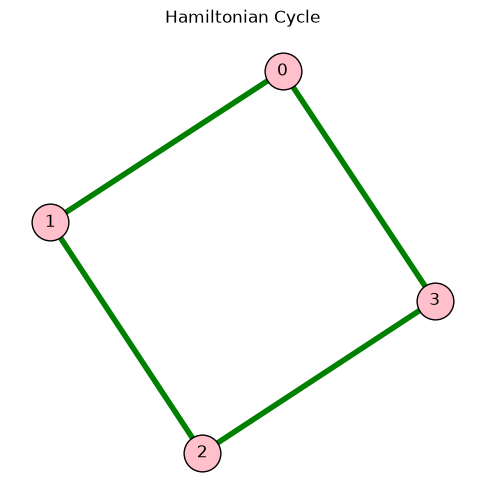

In [37]:
plot_hamiltonian_cycle(G, cycle, valid)

In [38]:
def hamiltonian_anneal(G):
    A = 8.0

    Q = build_hamiltonian_cycle(G, A)
    temps, energies, anneal_x = sim_annealing_QUBO(
            Q,
            T_start=10,
            T_end=0.01,
            alpha=0.99,
            sweeps_per_T=1000,
        )

    print("anneal")
    cycle, valid = read_hamiltonian_cycle(G, anneal_x)
    
    return temps, energies, anneal_x , cycle, valid

Lets try it with the bridge problem,


In [43]:
# 4 landmasses as nodes
# A = North bank, B = South bank, C = Kneiphof island, D = East bank
# 0=North(A), 1=South(B), 2=Island(C), 3=East(D)

G = nx.MultiGraph()
G.add_nodes_from([0, 1, 2, 3])  # 0=A, 1=B, 2=C, 3=D

G.add_edges_from([
    (0, 2), (0, 2),  # A-C x2
    (1, 2), (1, 2),  # B-C x2
    (0, 3),          # A-Ddef idx(v, j, N):
    (1, 3),          # B-D
    (2, 3),          # C-D
])

'''
def build_hamiltonian_cyce(G,A):
    N = G.number_of_nodes()
    Q = np.zeros((N*N, N*N))

    #nodes = list(G.nodes())
    #node_idx = {v: j for j, v in enumerate(nodes)}


    for v in range(N):
        # diagonal
        for j in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for j1 in range(N):
            for j2 in range(j1+1, N):
                Q[idx(v,j1,N), idx(v,j2,N)] += 2*A
                Q[idx(v,j2,N), idx(v,j1,N)] += 2*A
                
    for j in range(N):

        # diagonal
        for v in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for u in range(N):
            for v in range(u+1, N):
                Q[idx(u,j,N), idx(v,j,N)] += 2*A
                Q[idx(v,j,N), idx(u,j,N)] += 2*A
                
    for u in range(N):
        for v in range(N):

            if u == v:
                continue

            if not G.has_edge(u, v):

                for j in range(N):

                    jp = (j + 1) % N      # wrap around for Hamiltonian cycle

                    Q[idx(u,j,N), idx(v,jp,N)] += A
                    Q[idx(v,jp,N), idx(u,j,N)] += A
                    
    for u in range(N):
        for v in range(N):
            if u == v:
                continue

            if G.has_edge(u, v):
                for j in range(N):
            
    return Q

print(G)
temps, energies, anneal_x , cycle, valid =hamiltonian_anneal(G)
#plot_hamiltonian_cycle(G, cycle, valid)'''


'\ndef build_hamiltonian_cyce(G,A):\n    N = G.number_of_nodes()\n    Q = np.zeros((N*N, N*N))\n\n    #nodes = list(G.nodes())\n    #node_idx = {v: j for j, v in enumerate(nodes)}\n\n\n    for v in range(N):\n        # diagonal\n        for j in range(N):\n            Q[idx(v,j,N), idx(v,j,N)] -= A\n        # off-diagonal\n        for j1 in range(N):\n            for j2 in range(j1+1, N):\n                Q[idx(v,j1,N), idx(v,j2,N)] += 2*A\n                Q[idx(v,j2,N), idx(v,j1,N)] += 2*A\n\n    for j in range(N):\n\n        # diagonal\n        for v in range(N):\n            Q[idx(v,j,N), idx(v,j,N)] -= A\n        # off-diagonal\n        for u in range(N):\n            for v in range(u+1, N):\n                Q[idx(u,j,N), idx(v,j,N)] += 2*A\n                Q[idx(v,j,N), idx(u,j,N)] += 2*A\n\n    for u in range(N):\n        for v in range(N):\n\n            if u == v:\n                continue\n\n            if not G.has_edge(u, v):\n\n                for j in range(N):\n\n        

n = 13
Added 5 extra edges
Graph with 13 nodes and 18 edges
anneal
Cycle: [2, 1, 0, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3]
Missing edges: []
Valid: True


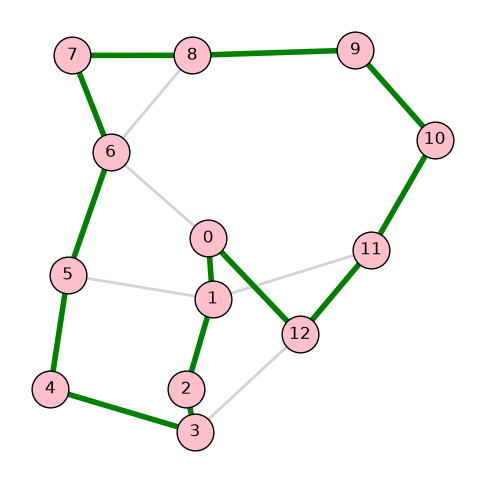

In [189]:
G = make_random_graph(13, 14)

print(G)
temps, energies, anneal_x , cycle, valid =hamiltonian_anneal(G)
plot_hamiltonian_cycle(G, cycle, valid)


# Travelling Salesman Problem
## building TSP
We take a hamiltion cycle graph $G(V,E)$, now each edge $(uv)$ has some weight $W_{uv}$ associated to each edge. Now we want to minimise the sum of he weights of each edge in the cycle.

$H_B= B\sum_{(uv)\in E}W_{uv}\sum_{j=1}^Nx_{u,j}x_{v,j+1}$

We need to ensure that the $H_A$ for the hamiltonian cycle is never violated, hence 

$0<B\max(W_{uv})<A$

So putting it all together,

$H= H_A+H_B=\\
~~=A\sum_{v=1}^n\left( - \sum_i^N x_{v,j}\\ + 2\sum_{i<j}^N x_{v,i}x_{v,j}\right)\\
~~ + A\sum_{j=1}^{N}\left(-\sum_{v=1}^{n}x_{v,j}+2\sum_{u<v}^nx_{u,j}x_{v,j}\right)\\
~~ + A\sum_{(uv)\notin E}\sum_{j=1}^N x_{u,j}x_{v,j+1}\\
~~ + B\sum_{(uv)\in E}W_{uv}\sum_{j=1}^Nx_{u,j}x_{v,j+1}$



**note** previously ive filled the whole of Q then you need to half the off diagonal coefficnet (I'm unsure if we did that previously). Instead I'm only going to fill the upper triangle

In [45]:
def idx(v, j, N):
    return v * N + j

def build_tsp(G,A,B):
    N = G.number_of_nodes()
    Q = np.zeros((N*N, N*N))
    
    nodes = list(G.nodes())
    weights = nx.get_edge_attributes(G, "weight")

    # hamiltionan cycle code
    for v in range(N):
        # diagonal
        for j in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for j1 in range(N):
            for j2 in range(j1+1, N):
                Q[idx(v,j1,N), idx(v,j2,N)] += 2*A
                
    for j in range(N):

        # diagonal
        for v in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for u in range(N):
            for v in range(u+1, N):
                Q[idx(u,j,N), idx(v,j,N)] += 2*A
                
    for u in range(N):
        for v in range(N):

            if u == v:
                continue

            if not G.has_edge(u, v):

                for j in range(N):

                    jp = (j + 1) % N   

                    Q[idx(u,j,N), idx(v,jp,N)] += A
     
     
    # additional H_B term for TSP  
    weights = nx.get_edge_attributes(G, 'weight')
        
    for u in range(N):
        for v in range(N):
            if u == v:
                continue

            if G.has_edge(nodes[u], nodes[v]):
                w = weights.get((nodes[u], nodes[v]),
                    weights.get((nodes[v], nodes[u]), 1.0))
                for j in range(N):
                    jp = (j + 1) % N
                    Q[idx(u,j,N), idx(v,jp,N)] += B * w
    return Q


In [46]:
def read_tsp(G, x, verbose=False):

    N = G.number_of_nodes()
    cycle = [None] * N
    valid = True

    for v in range(N):
        positions = [j for j in range(N) if x[idx(v, j, N)] == 1]
        if len(positions) != 1:
            print(f"Vertex {v}: invalid positions {positions}")
            valid = False
        else:
            cycle[positions[0]] = v

    for j in range(N):
        vertices = [v for v in range(N) if x[idx(v, j, N)] == 1]
        if len(vertices) != 1:
            print(f"Position {j}: invalid vertices {vertices}")
            valid = False

    missing_edges = []
    total_weight = 0.0

    if valid:
        for j in range(N):
            u = cycle[j]
            v = cycle[(j + 1) % N]
            if not G.has_edge(u, v):
                missing_edges.append((u, v))
            else:
                total_weight += G[u][v]['weight']

        if missing_edges:
            valid = False
            
    if verbose == True:
        print(f"Cycle: {cycle}")
        print(f"Missing edges: {missing_edges}")
        print(f"Total weight: {total_weight:.2f}")
        print(f"Valid: {valid}")

    return cycle, valid

In [ ]:
def tsp_anneal(G,A,B, T_start ,T_end , alpha , sweeps_per_T):
    #its currently stupid T_start ,T_end are inputed then re-asigned, im too lazy to completely re do it
    Q = build_tsp(G, A,B)
    
    #its currently stupid T_start ,T_end are inputed then re-asigned, im too lazy to completely re do it
    T_start, T_end, _ =estimate_temperature_range(Q)
    
    temps, energies, anneal_x = sim_annealing_QUBO_converge(Q, alpha=0.999, window=50, tol=1e-3, max_sweeps=7000,verbose=False)
    
    # currently stupid ik
    '''= sim_annealing_QUBO(
            Q,
            T_start,
            T_end,
            alpha,
            sweeps_per_T,
        )'''

    #print("anneal")
    cycle, valid = read_tsp(G, anneal_x)
    
    return temps, energies, anneal_x , cycle, valid

In [117]:
def plot_tsp(G, cycle, valid, pos=None,C=None,Name=None):
    if not valid:
        print("Cannot plot: invalid TSP cycle.")
        return 1000

    # Use supplied coordinates if available
    if pos is None:
        pos = nx.spring_layout(G, seed=1)

    plt.figure(figsize=(6, 6))

    # all edges in grey
    nx.draw_networkx_edges(G, pos, edge_color="lightgrey", width=2)

    # cycle edges in green
    N = len(cycle)
    cycle_edges = [
        (cycle[i], cycle[(i + 1) % N])
        for i in range(N)
    ]

    nx.draw_networkx_edges(
        G, pos,
        edgelist=cycle_edges,
        edge_color="green",
        width=4
    )

    # nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color="pink",
        node_size=700,
        edgecolors="black"
    )
    nx.draw_networkx_labels(G, pos)

    # edge labels
    weights = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels={e: f"{w:.2f}" for e, w in weights.items()},
        rotate=False
    )

    total = sum(
        G[cycle[i]][cycle[(i + 1) % N]]["weight"]
        for i in range(N)
    )

    plt.title(f"TSP Cycle |Type: {Name}| Total weight = {total:.2f}")
    plt.axis("equal")
    plt.axis("off")
    
    plt.savefig(f"/home/cian/Documents/college/SURE/git/QUBO/example-problems/fig/C/tsp-{C}-{Name}.pdf")

    
    plt.show()

    return total

### testing paramters
Remember $0<B\max(W_{uv})<A$, so lets let $B=1$ $A=C\cdot B\cdot\max(W_{uv})$,

we need to tweak $C$ such that we always get a valid state and the lowest $\sum_{(uv)\in E} W_{uv}$.

We want to plot $E$ vs $T$ as it anneals to get an idea of annealing.

In [118]:
def plot_TvE(temps, energies,C):
    plt.figure(figsize=(8, 4))
    plt.plot(temps, energies, color='steelblue', linewidth=1)
    plt.xlabel('Temperature')
    plt.ylabel('Energy')
    plt.title(f'Energy vs Temperature (for C:{C})')
    plt.xscale('log')
    plt.gca().invert_xaxis()  # time flows left to right: hot → cold
    plt.axhline(y=min(energies), color='red', linestyle='--', 
                label=f'min E = {min(energies):.2f}')
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(f"/home/cian/Documents/college/SURE/git/QUBO/example-problems/fig/C/TvE-{C}.pdf")

    plt.show()

Testing this for different values of C
C: [100.0, 50.0, 5.0, 1.1, 1.0] 

C= 100.0
Then, A: 900.0
Validity of the run: True
Brute force minimum energy: -7179.00
Brute force TSP plot:


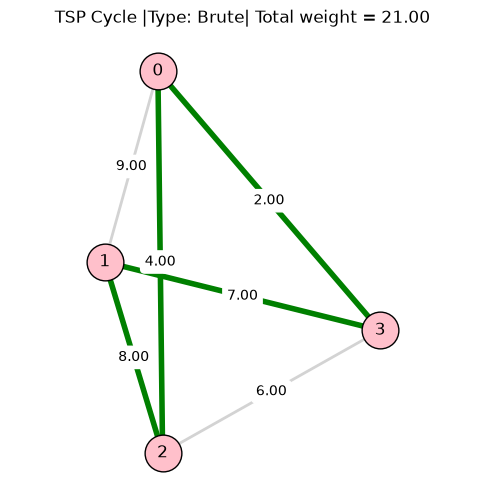

sum W : 21
sum W : 21
Anneal the same Q 3s to compare,

Annealing run 1

Validity of the run: True
Annealing TSP plot 1:


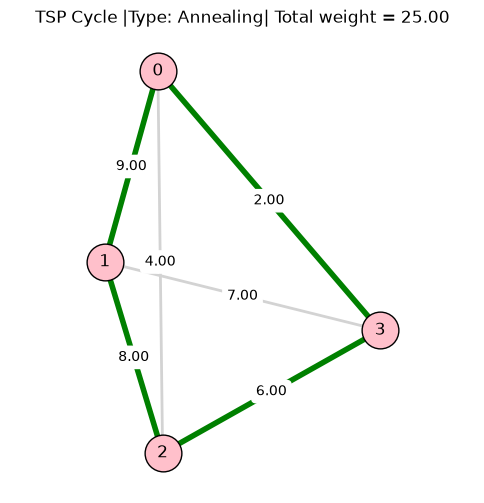

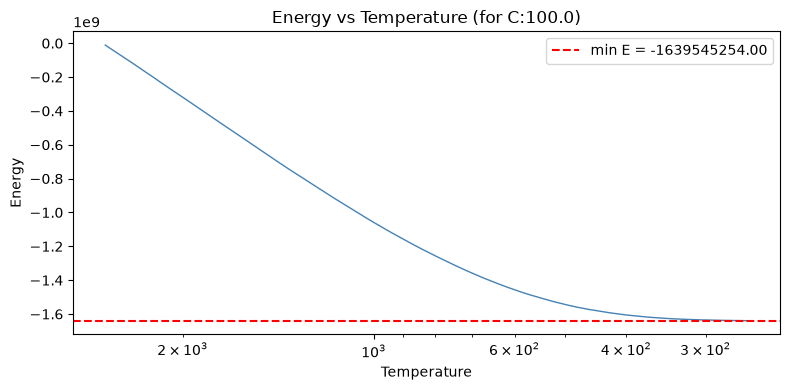

That gives us  sum of W=25
There is a difference of -4 between at 100.0

Annealing run 2

Validity of the run: True
Annealing TSP plot 2:


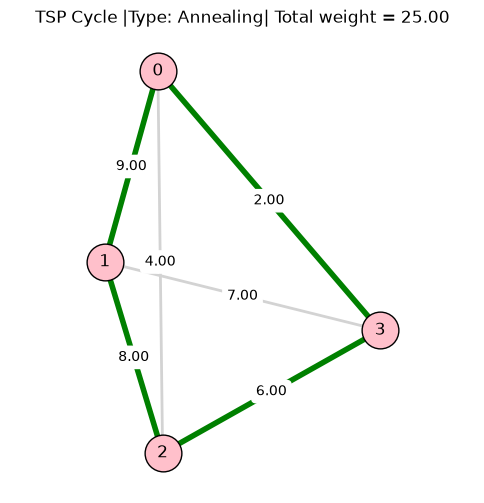

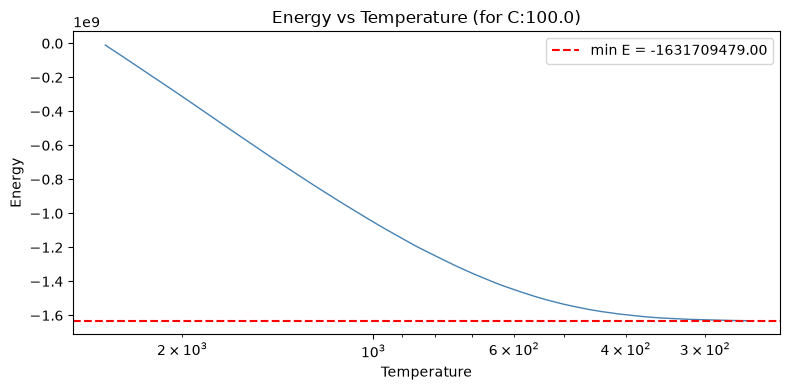

That gives us  sum of W=25
There is a difference of -4 between at 100.0

Annealing run 3

Validity of the run: True
Annealing TSP plot 3:


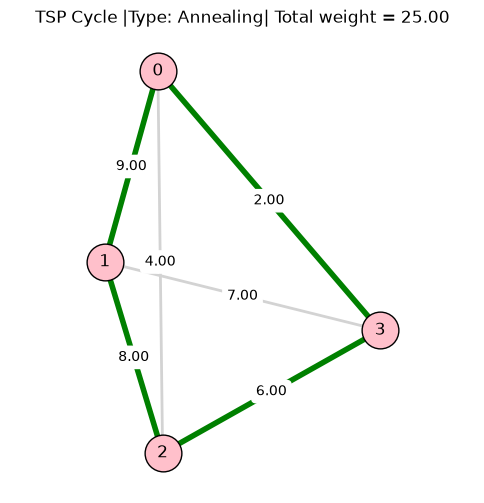

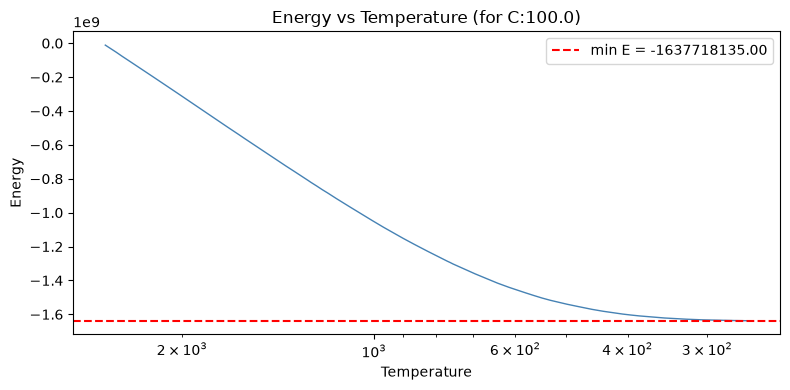

That gives us  sum of W=25
There is a difference of -4 between at 100.0

Annealing run 4

Validity of the run: True
Annealing TSP plot 4:


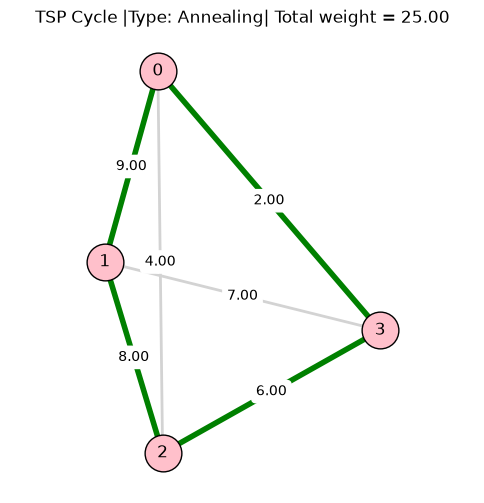

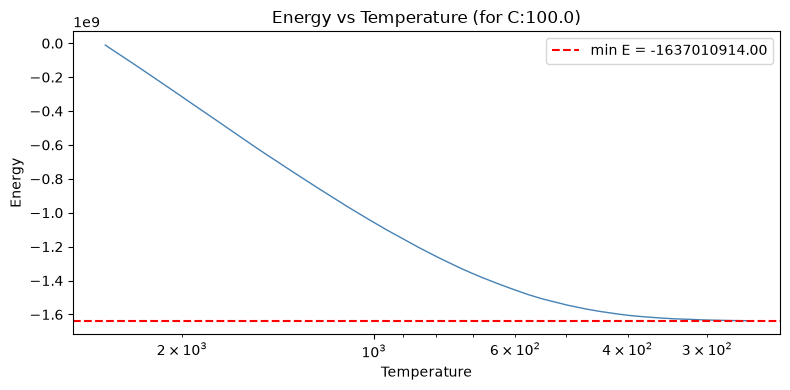

That gives us  sum of W=25
There is a difference of -4 between at 100.0


C:
 [100.0, 100.0, 100.0, 100.0]
differnce between annealing and bf for W sum
 [-4, -4, -4, -4]
C= 50.0
Then, A: 450.0
Validity of the run: True
Brute force minimum energy: -3579.00
Brute force TSP plot:


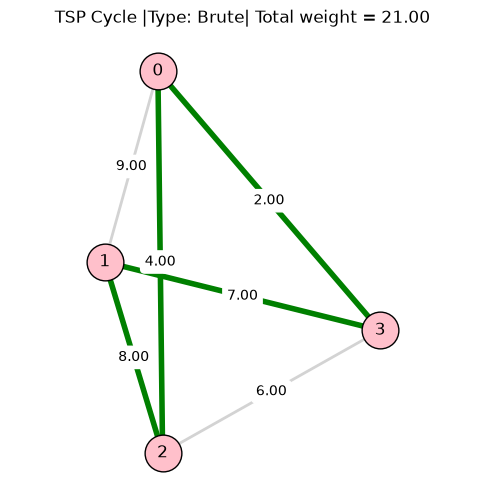

sum W : 21
sum W : 21
Anneal the same Q 3s to compare,

Annealing run 1

Validity of the run: True
Annealing TSP plot 1:


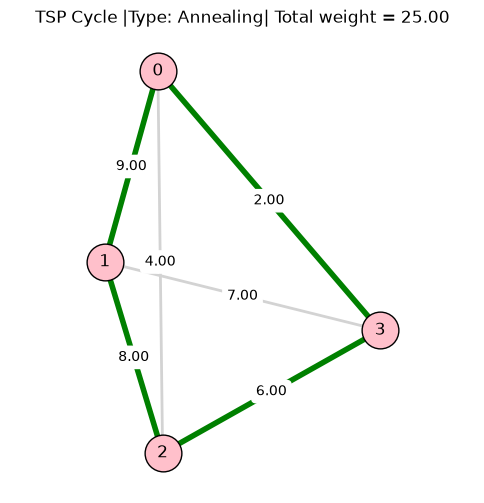

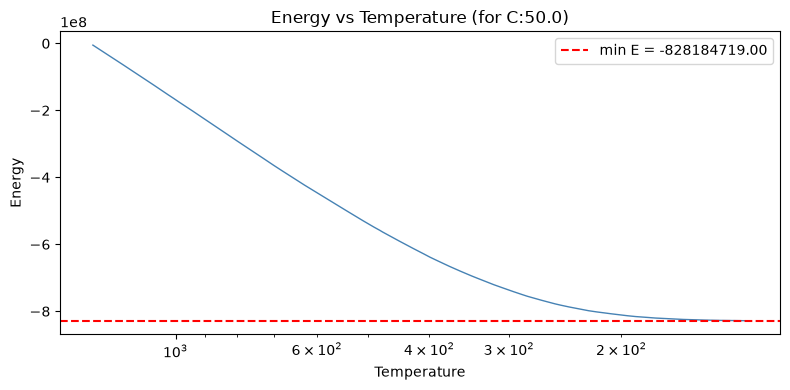

That gives us  sum of W=25
There is a difference of -4 between at 50.0

Annealing run 2

Validity of the run: True
Annealing TSP plot 2:


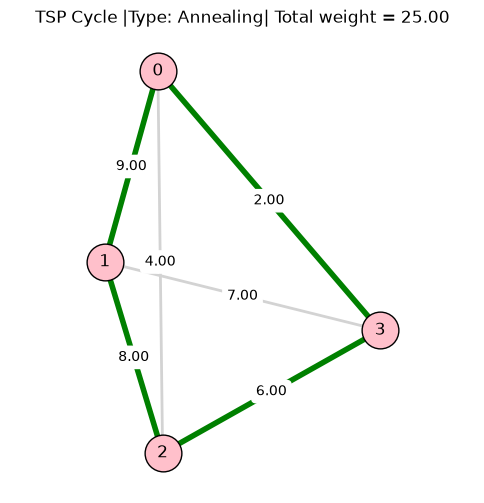

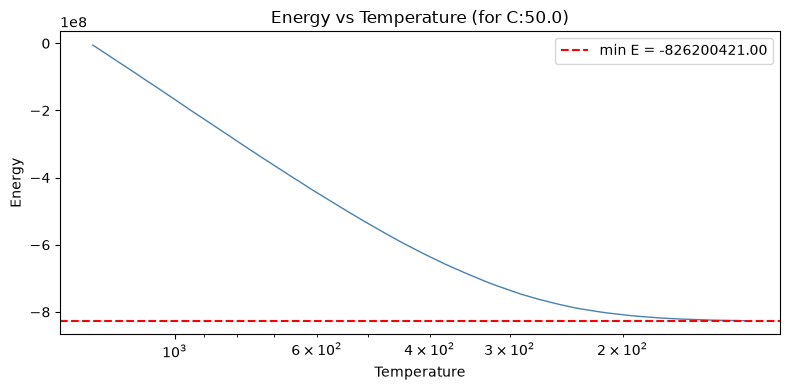

That gives us  sum of W=25
There is a difference of -4 between at 50.0

Annealing run 3

Validity of the run: True
Annealing TSP plot 3:


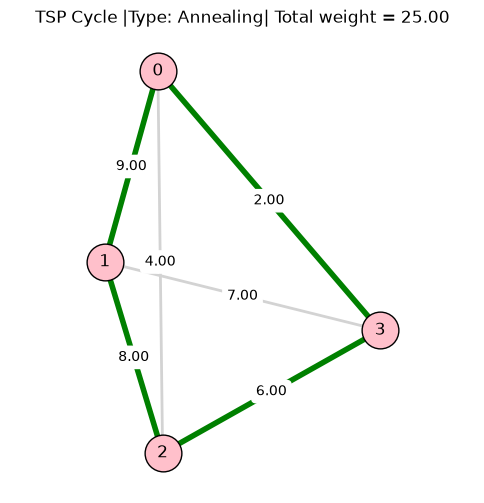

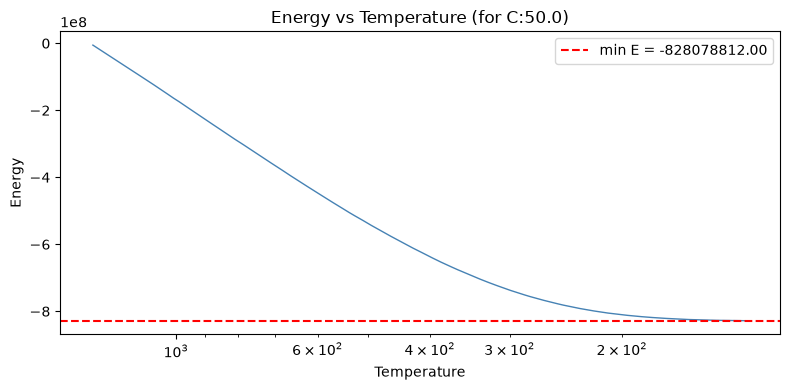

That gives us  sum of W=25
There is a difference of -4 between at 50.0

Annealing run 4

Validity of the run: True
Annealing TSP plot 4:


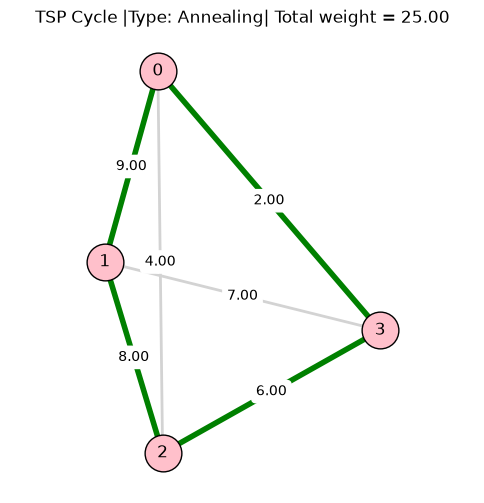

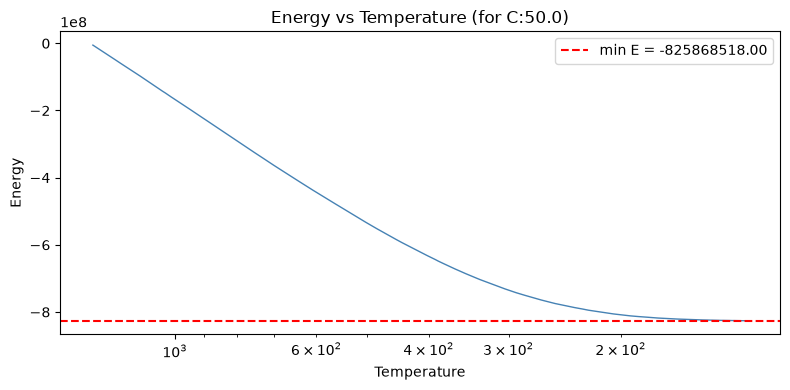

That gives us  sum of W=25
There is a difference of -4 between at 50.0


C:
 [100.0, 100.0, 100.0, 100.0, 50.0, 50.0, 50.0, 50.0]
differnce between annealing and bf for W sum
 [-4, -4, -4, -4, -4, -4, -4, -4]
C= 5.0
Then, A: 45.0
Validity of the run: True
Brute force minimum energy: -339.00
Brute force TSP plot:


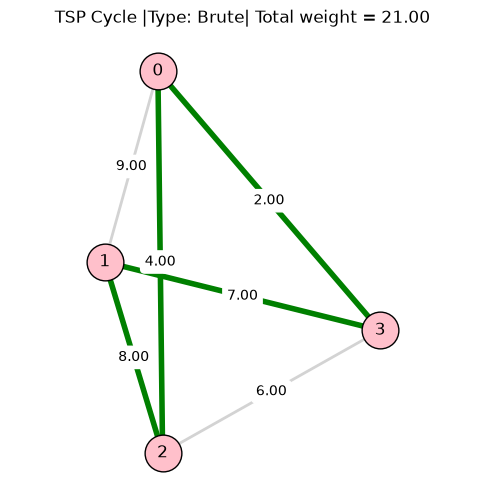

sum W : 21
sum W : 21
Anneal the same Q 3s to compare,

Annealing run 1

Validity of the run: True
Annealing TSP plot 1:


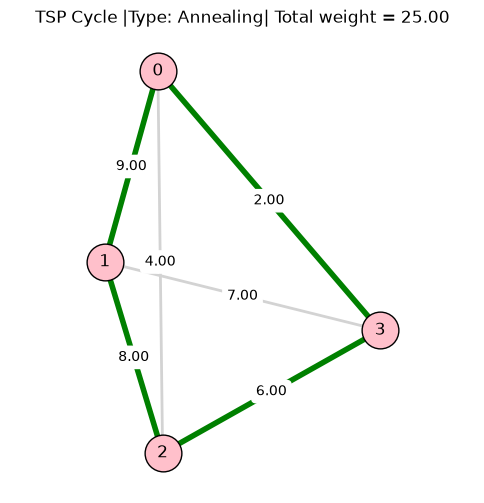

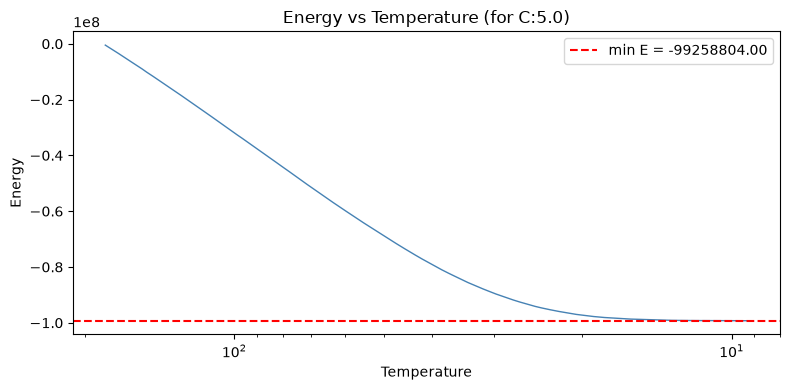

That gives us  sum of W=25
There is a difference of -4 between at 5.0

Annealing run 2

Validity of the run: True
Annealing TSP plot 2:


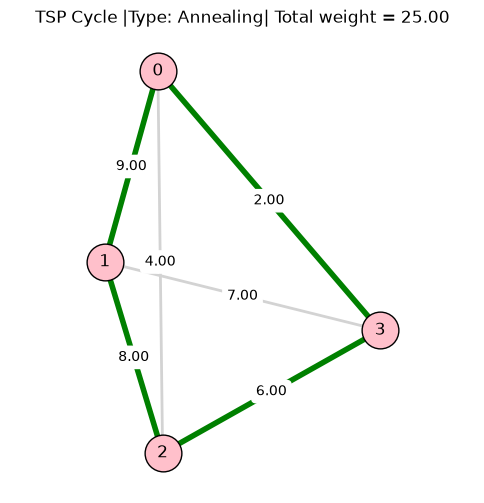

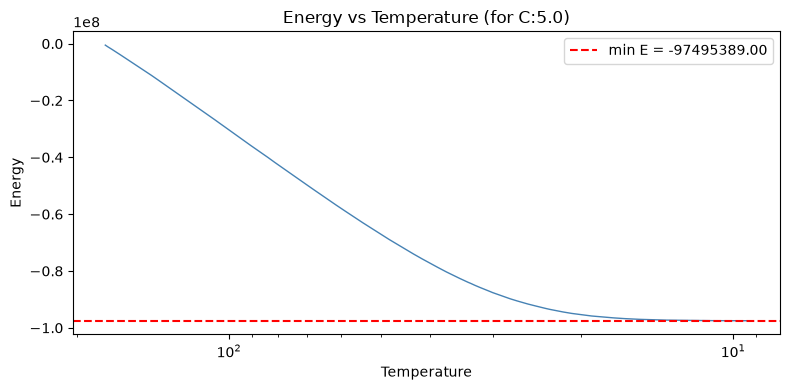

That gives us  sum of W=25
There is a difference of -4 between at 5.0

Annealing run 3

Validity of the run: True
Annealing TSP plot 3:


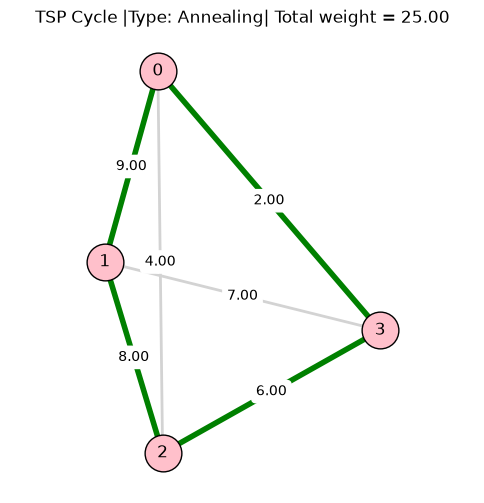

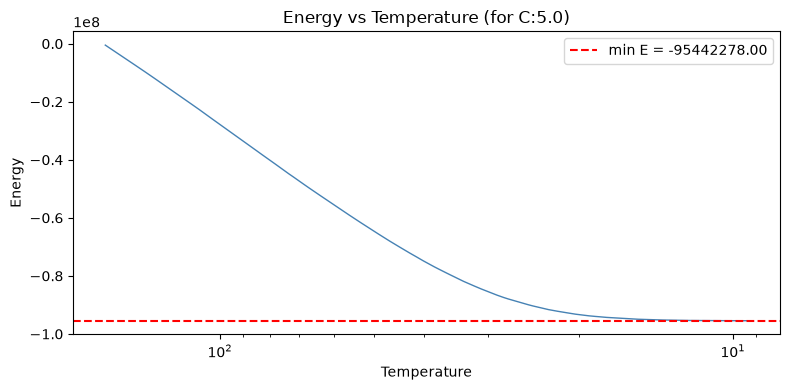

That gives us  sum of W=25
There is a difference of -4 between at 5.0

Annealing run 4

Validity of the run: True
Annealing TSP plot 4:


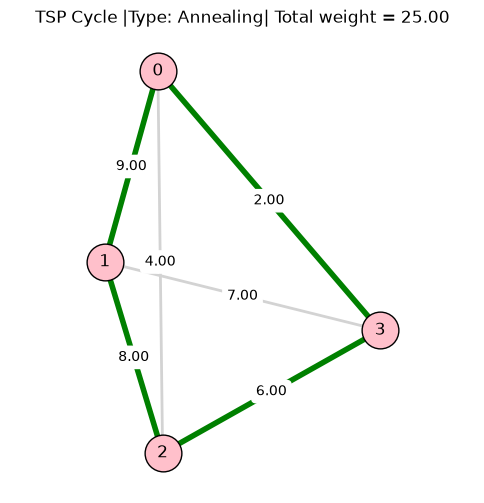

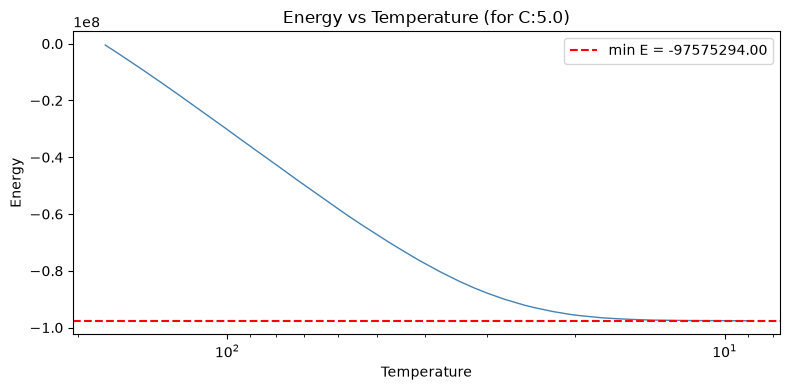

That gives us  sum of W=25
There is a difference of -4 between at 5.0


C:
 [100.0, 100.0, 100.0, 100.0, 50.0, 50.0, 50.0, 50.0, 5.0, 5.0, 5.0, 5.0]
differnce between annealing and bf for W sum
 [-4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4]
C= 1.1
Then, A: 9.9
Validity of the run: True
Brute force minimum energy: -58.20
Brute force TSP plot:


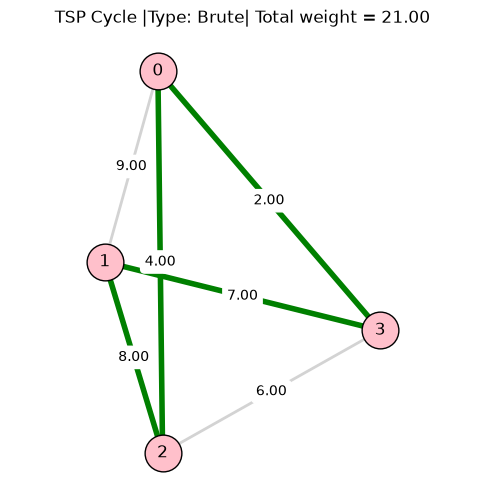

sum W : 21
sum W : 21
Anneal the same Q 3s to compare,

Annealing run 1

Validity of the run: True
Annealing TSP plot 1:


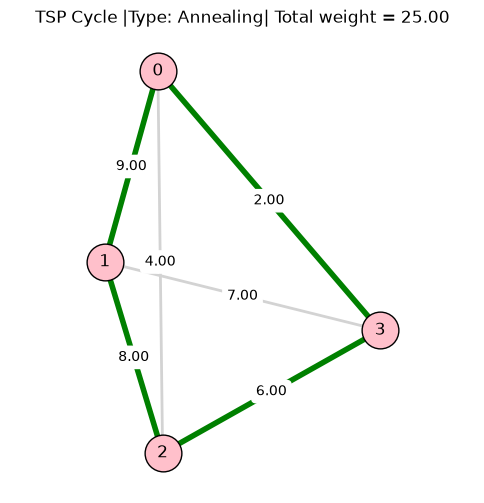

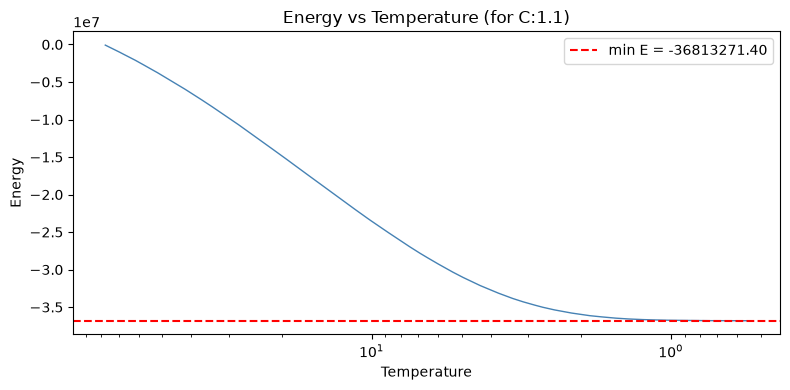

That gives us  sum of W=25
There is a difference of -4 between at 1.1

Annealing run 2

Validity of the run: True
Annealing TSP plot 2:


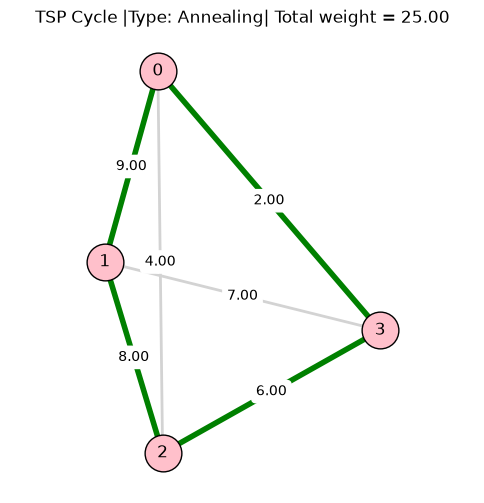

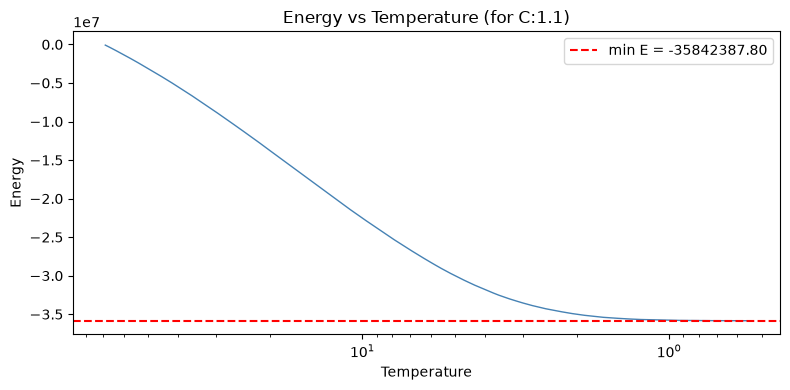

That gives us  sum of W=25
There is a difference of -4 between at 1.1

Annealing run 3

Vertex 0: invalid positions []
Position 0: invalid vertices []
Validity of the run: False
Annealing TSP plot 3:
Cannot plot: invalid TSP cycle.


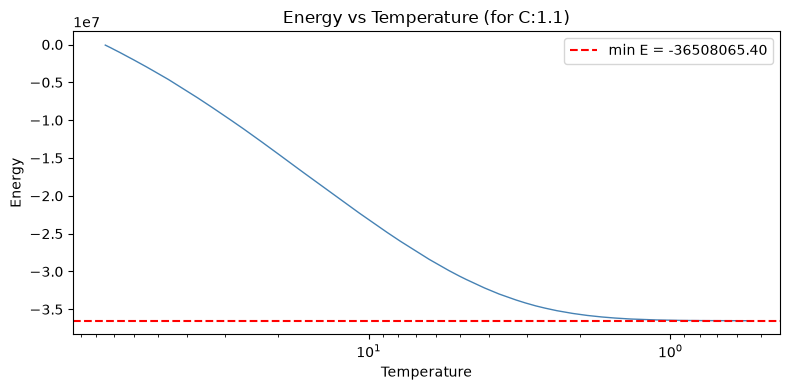

That gives us  sum of W=1000
There is a difference of -979 between at 1.1

Annealing run 4

Validity of the run: True
Annealing TSP plot 4:


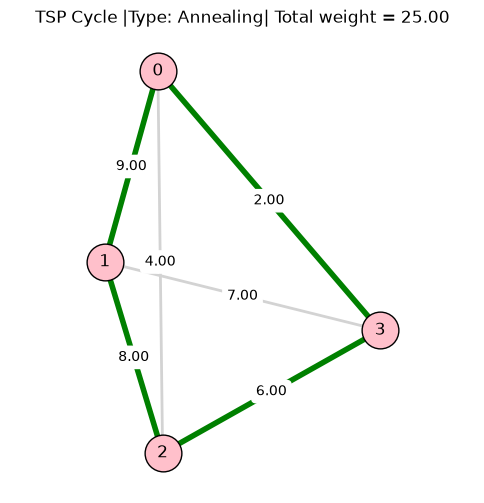

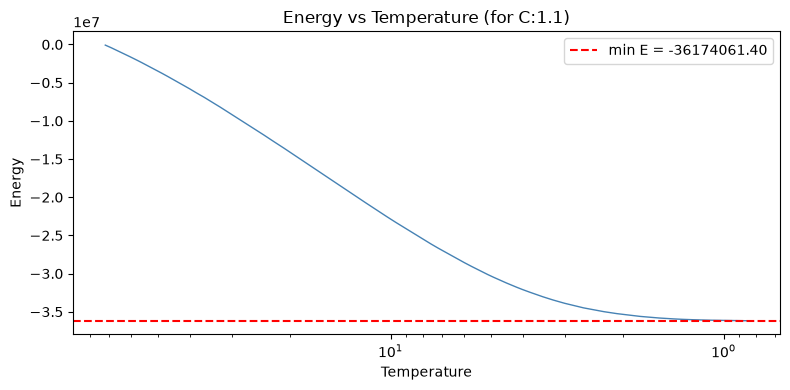

That gives us  sum of W=25
There is a difference of -4 between at 1.1


C:
 [100.0, 100.0, 100.0, 100.0, 50.0, 50.0, 50.0, 50.0, 5.0, 5.0, 5.0, 5.0, 1.1, 1.1, 1.1, 1.1]
differnce between annealing and bf for W sum
 [-4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -979, -4]
C= 1.0
Then, A: 9.0
Validity of the run: True
Brute force minimum energy: -51.00
Brute force TSP plot:


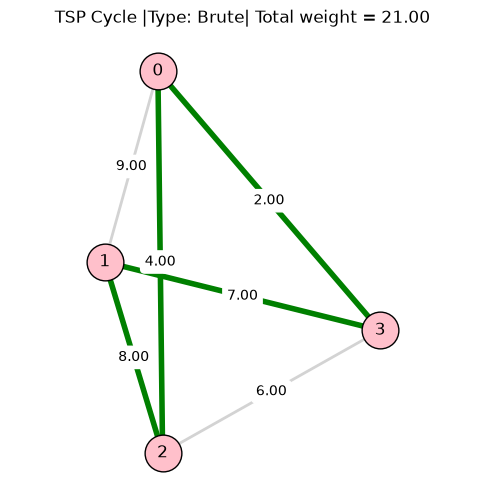

sum W : 21
sum W : 21
Anneal the same Q 3s to compare,

Annealing run 1

Vertex 0: invalid positions []
Position 0: invalid vertices []
Validity of the run: False
Annealing TSP plot 1:
Cannot plot: invalid TSP cycle.


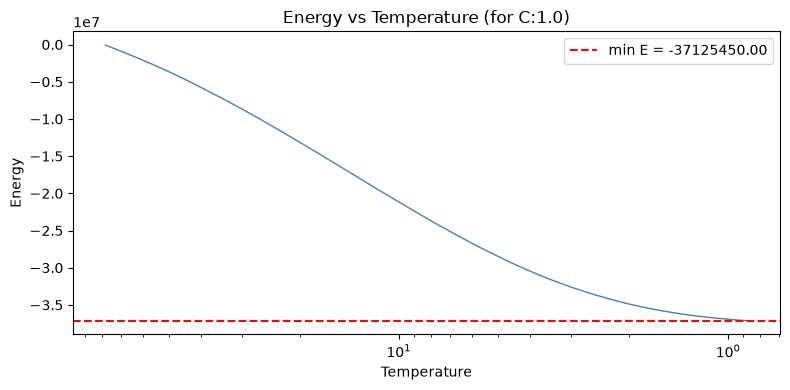

That gives us  sum of W=1000
There is a difference of -979 between at 1.0

Annealing run 2

Vertex 0: invalid positions []
Position 0: invalid vertices []
Validity of the run: False
Annealing TSP plot 2:
Cannot plot: invalid TSP cycle.


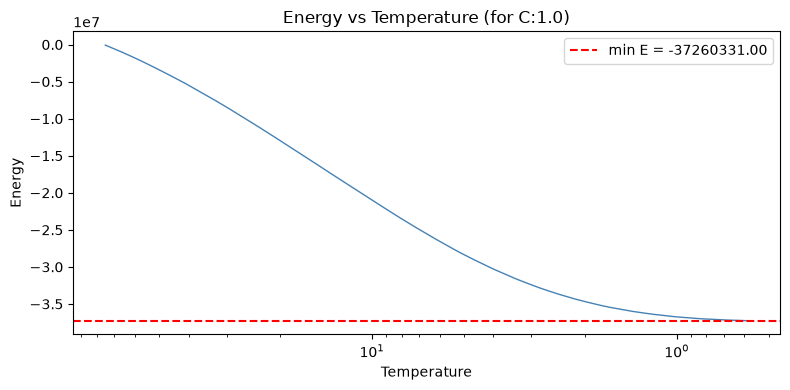

That gives us  sum of W=1000
There is a difference of -979 between at 1.0

Annealing run 3

Validity of the run: True
Annealing TSP plot 3:


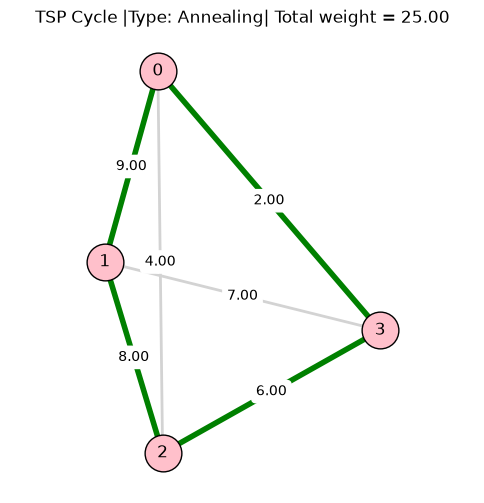

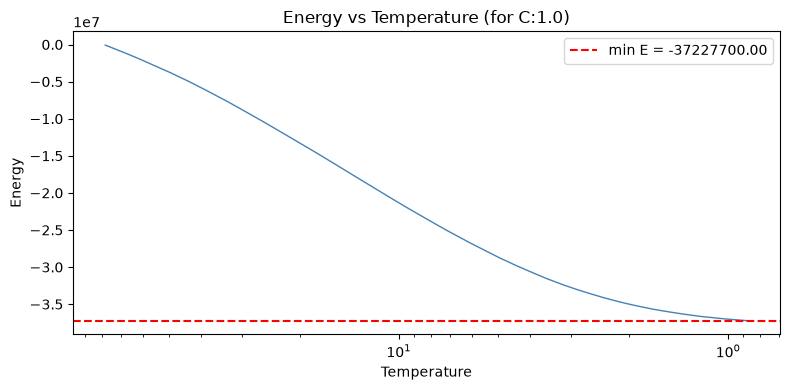

That gives us  sum of W=25
There is a difference of -4 between at 1.0

Annealing run 4

Vertex 0: invalid positions []
Position 0: invalid vertices []
Validity of the run: False
Annealing TSP plot 4:
Cannot plot: invalid TSP cycle.


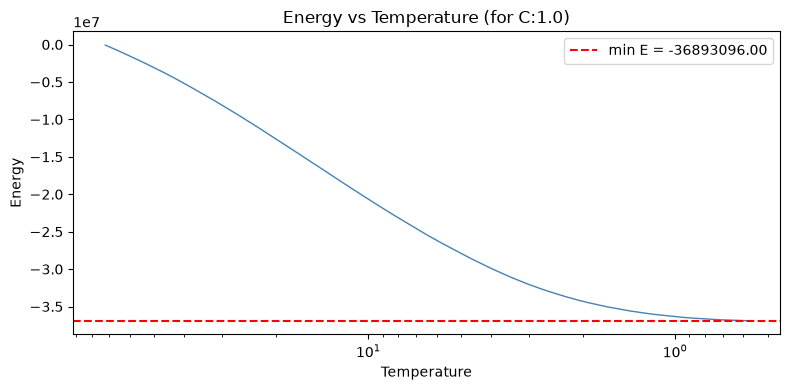

That gives us  sum of W=1000
There is a difference of -979 between at 1.0


C:
 [100.0, 100.0, 100.0, 100.0, 50.0, 50.0, 50.0, 50.0, 5.0, 5.0, 5.0, 5.0, 1.1, 1.1, 1.1, 1.1, 1.0, 1.0, 1.0, 1.0]
differnce between annealing and bf for W sum
 [-4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -979, -4, -979, -979, -4, -979]


In [123]:
G = nx.complete_graph(4)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.randint(1, 10)

W = nx.to_numpy_array(G, weight='weight')

Cs= [100.0,50.0,5.0,1.1,1.0]
#Cs=[1]
C_vals = []
diffs = []

print("Testing this for different values of C")
print("C:",Cs, "\n")

for C in Cs:
    print("C=", C)
    #set up
    B = 1
    A = C * B * W.max()
    print("Then, A:", A)
    Q = build_tsp(G, A, B)
    #print("Q:\n",Q)
    
    # brute force 
    best_E, best_x = brute_force_qubo(Q)
    bf_cycle, bf_valid = read_tsp(G, best_x)
    print(f"Validity of the run: {bf_valid}")
    print(f"Brute force minimum energy: {best_E:.2f}")
    
    print("Brute force TSP plot:")
    bf_wsum=plot_tsp(G, bf_cycle, bf_valid, C=C,Name="Brute")
    if bf_valid:
        N = len(bf_cycle)
        bf_wsum = sum(
            G[bf_cycle[i]][bf_cycle[(i + 1) % N]]["weight"]
            for i in range(N)
        )
        print("sum W :", bf_wsum)
    print("sum W :", bf_wsum)
    
    #annealing
    print("Anneal the same Q 3s to compare,")
    for i in range(4):
        print(f"\nAnnealing run {i+1}\n")
        temps, energies, anneal_x , cycle, valid = tsp_anneal(G,A,B,
                T_start=max(10*C, 50),
                T_end=0.001,
                alpha=0.99,
                sweeps_per_T=2000)
        #cycle, valid = read_tsp(G, anneal_x) alread in tsp anneal
        print(f"Validity of the run: {valid}")
        print(f"Annealing TSP plot {i+1}:")
        sumW = plot_tsp(G, cycle, valid,pos=None, C=C,Name="Annealing")
        plot_TvE(temps, energies, C)
        print(f"That gives us  sum of W={sumW}")
        diff= bf_wsum - sumW
        print(f"There is a difference of {diff} between at {C}")
        
        C_vals.append(C)
        diffs.append(diff)
        
    print("\n")
    
    print("C:\n", C_vals)
    print("differnce between annealing and bf for W sum\n",diffs)
    


Running this with smallers C's to test we find,

Testing this for different values of C
C: [1.5, 1.2, 1.1, 1] 

C= 1.5
Then, A: 13.5
Validity of the run: True
Brute force minimum energy: -86.00
Brute force TSP plot:


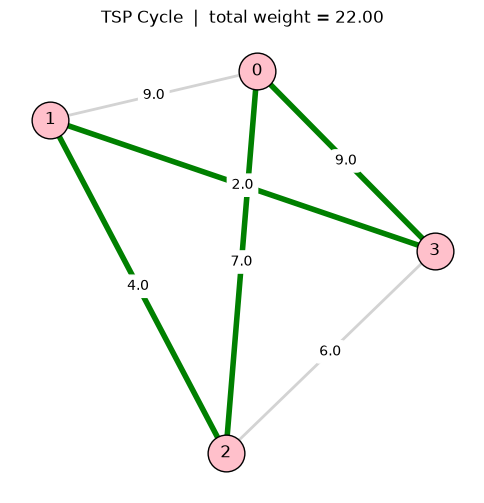

sum W : 22
Anneal the same Q 3s to compare,

Annealing run 1

anneal
Validity of the run: True
Annealing TSP plot 1:


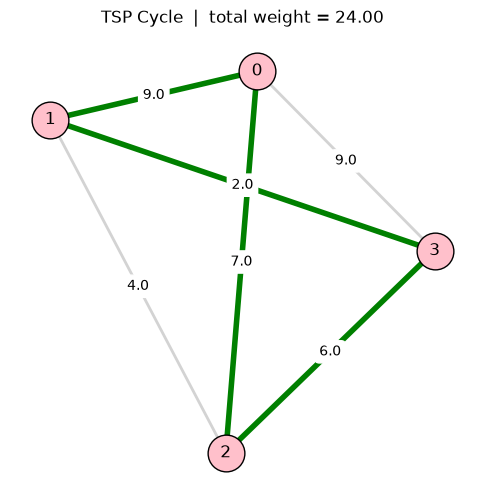

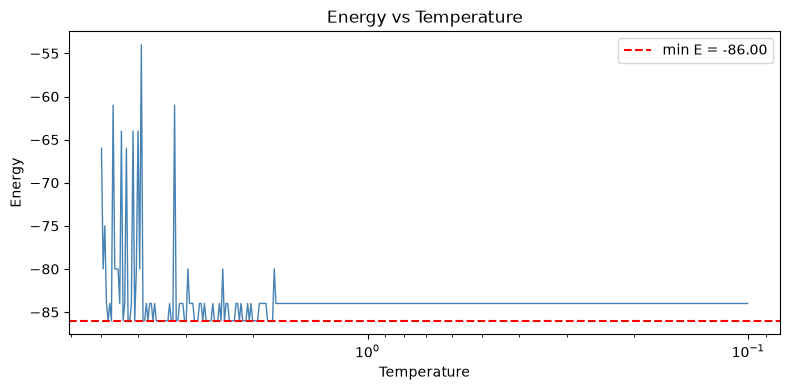

That gives us  sum of W=24
There is a difference of -2 between at 1.5

Annealing run 2

anneal
Validity of the run: True
Annealing TSP plot 2:


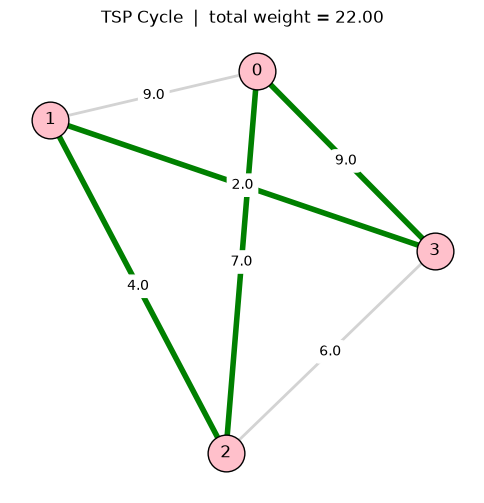

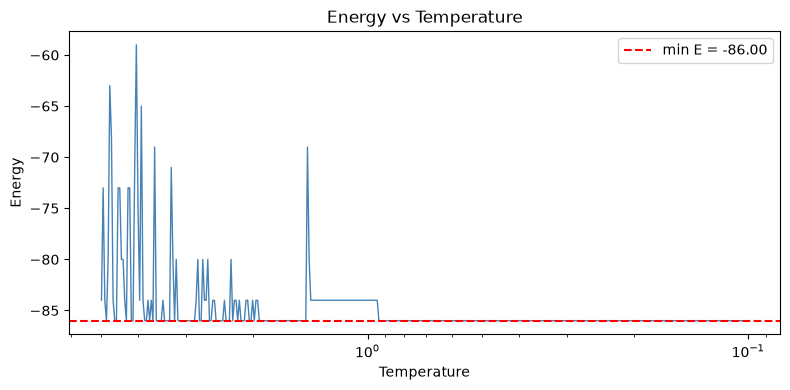

That gives us  sum of W=22
There is a difference of 0 between at 1.5

Annealing run 3

anneal
Validity of the run: True
Annealing TSP plot 3:


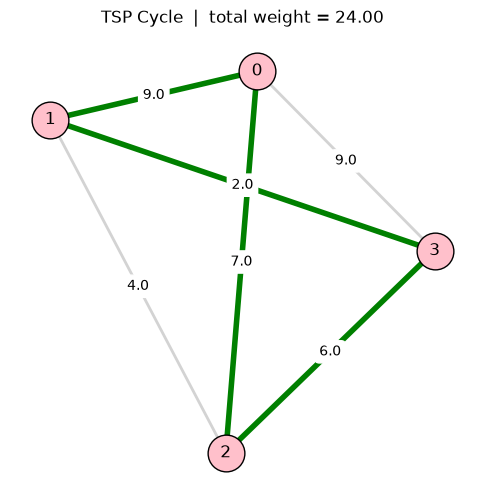

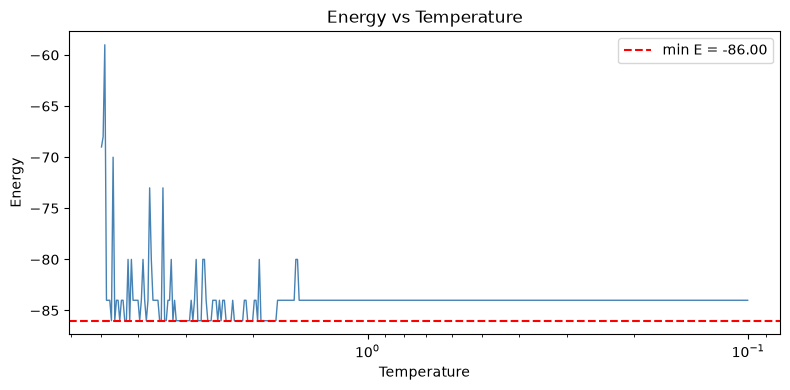

That gives us  sum of W=24
There is a difference of -2 between at 1.5


C:
 [1.5, 1.5, 1.5]
differnce between annealing and bf for W sum
 [-2, 0, -2]
C= 1.2
Then, A: 10.799999999999999
Validity of the run: True
Brute force minimum energy: -64.40
Brute force TSP plot:


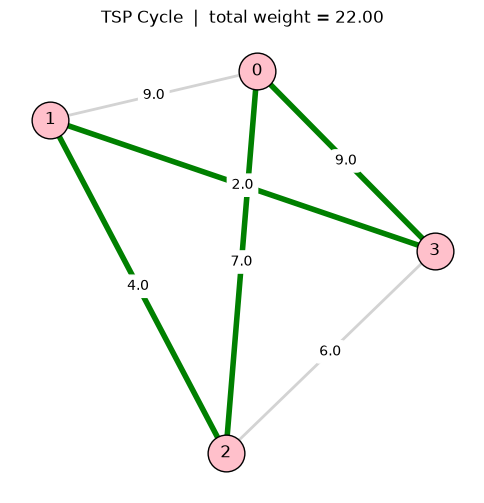

sum W : 22
Anneal the same Q 3s to compare,

Annealing run 1

anneal
Validity of the run: True
Annealing TSP plot 1:


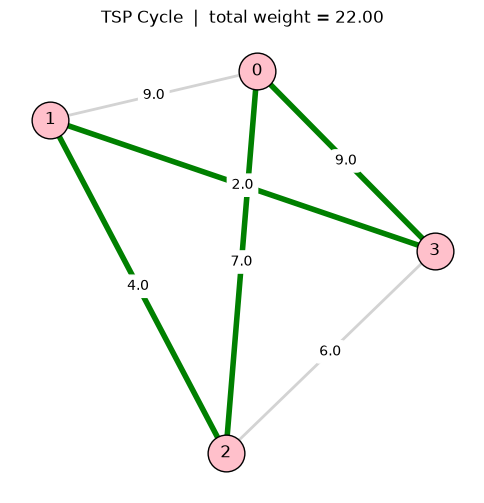

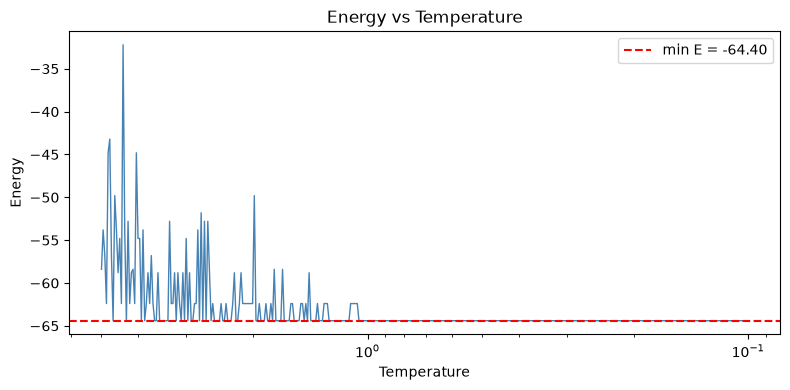

That gives us  sum of W=22
There is a difference of 0 between at 1.2

Annealing run 2

anneal
Validity of the run: True
Annealing TSP plot 2:


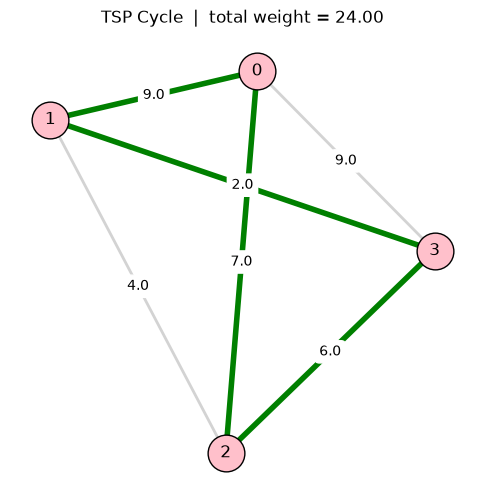

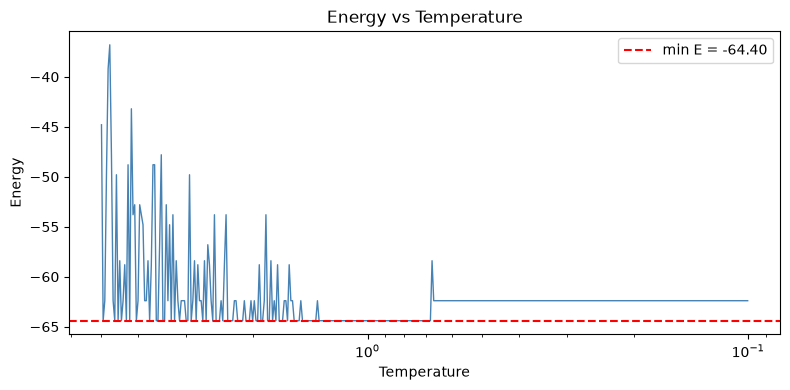

That gives us  sum of W=24
There is a difference of -2 between at 1.2

Annealing run 3

anneal
Validity of the run: True
Annealing TSP plot 3:


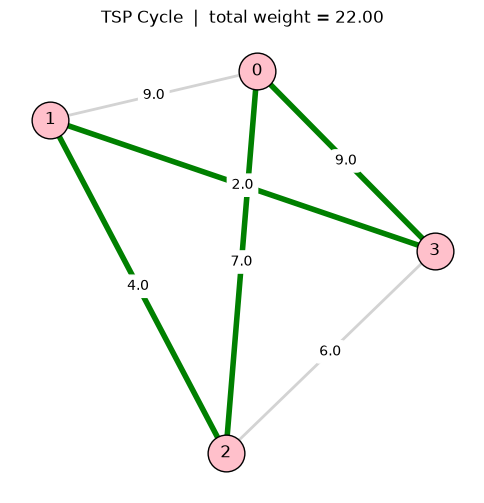

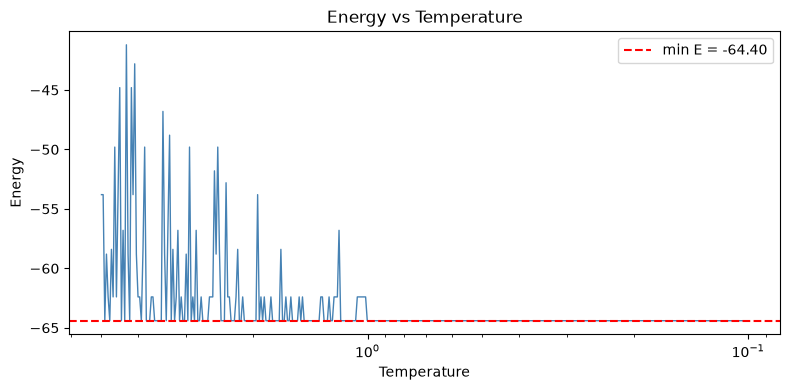

That gives us  sum of W=22
There is a difference of 0 between at 1.2


C:
 [1.5, 1.5, 1.5, 1.2, 1.2, 1.2]
differnce between annealing and bf for W sum
 [-2, 0, -2, 0, -2, 0]
C= 1.1
Then, A: 9.9
Validity of the run: True
Brute force minimum energy: -57.20
Brute force TSP plot:


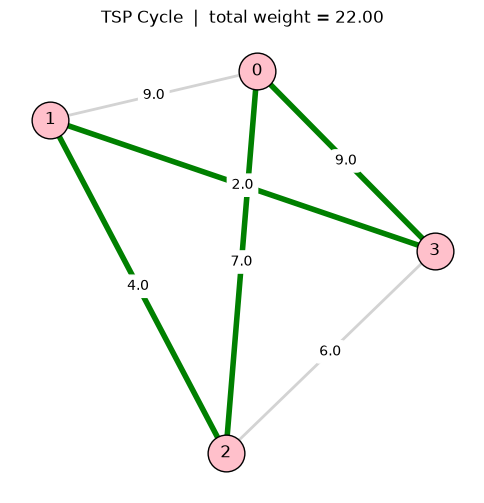

sum W : 22
Anneal the same Q 3s to compare,

Annealing run 1

anneal
Validity of the run: True
Annealing TSP plot 1:


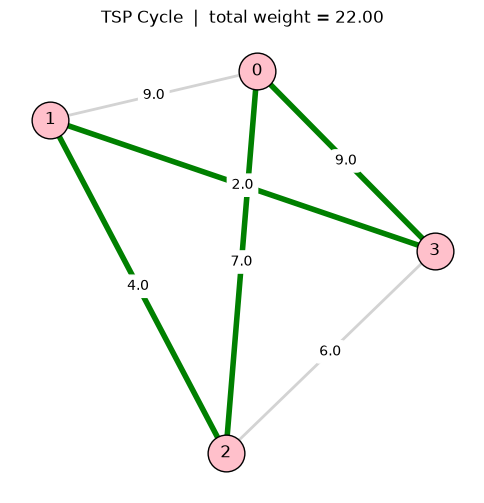

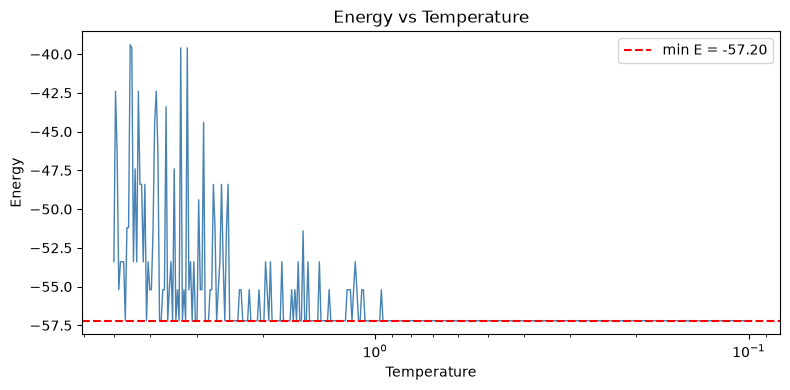

That gives us  sum of W=22
There is a difference of 0 between at 1.1

Annealing run 2

anneal
Validity of the run: True
Annealing TSP plot 2:


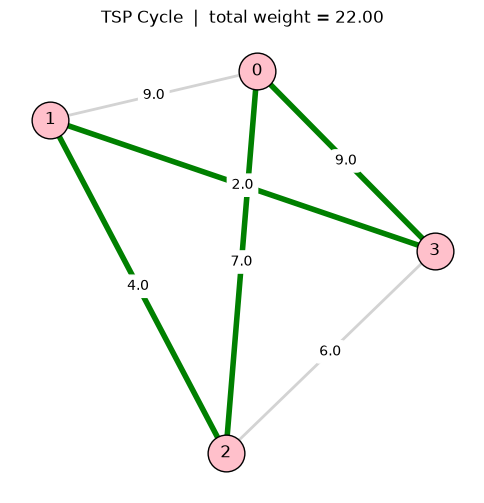

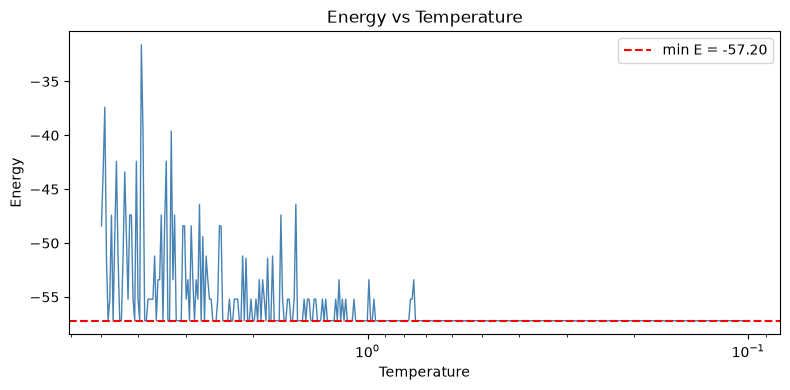

That gives us  sum of W=22
There is a difference of 0 between at 1.1

Annealing run 3

anneal
Validity of the run: True
Annealing TSP plot 3:


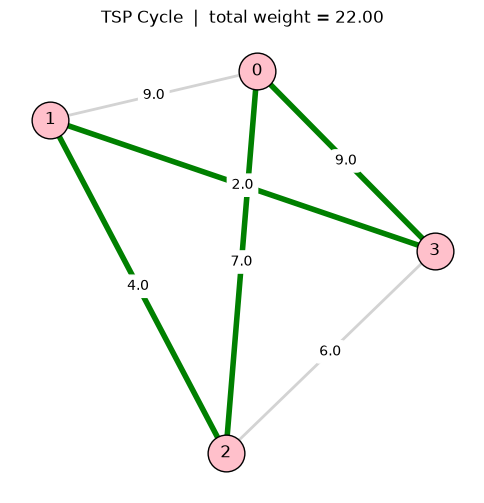

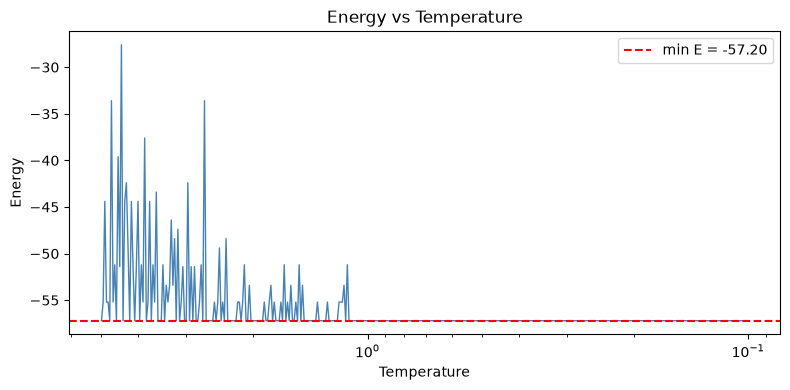

That gives us  sum of W=22
There is a difference of 0 between at 1.1


C:
 [1.5, 1.5, 1.5, 1.2, 1.2, 1.2, 1.1, 1.1, 1.1]
differnce between annealing and bf for W sum
 [-2, 0, -2, 0, -2, 0, 0, 0, 0]
C= 1
Then, A: 9.0
Validity of the run: True
Brute force minimum energy: -50.00
Brute force TSP plot:


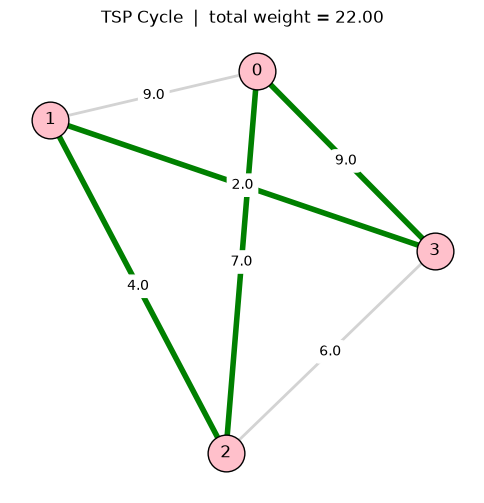

sum W : 22
Anneal the same Q 3s to compare,

Annealing run 1

anneal
Validity of the run: True
Annealing TSP plot 1:


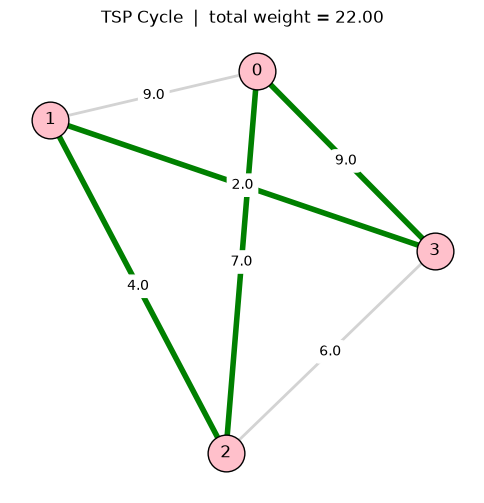

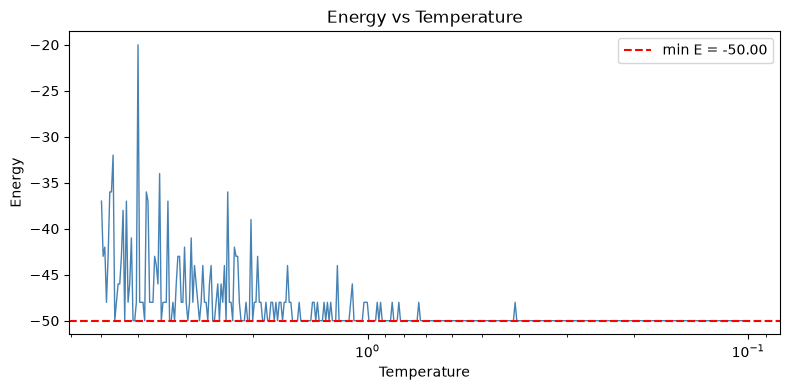

That gives us  sum of W=22
There is a difference of 0 between at 1

Annealing run 2

anneal
Validity of the run: True
Annealing TSP plot 2:


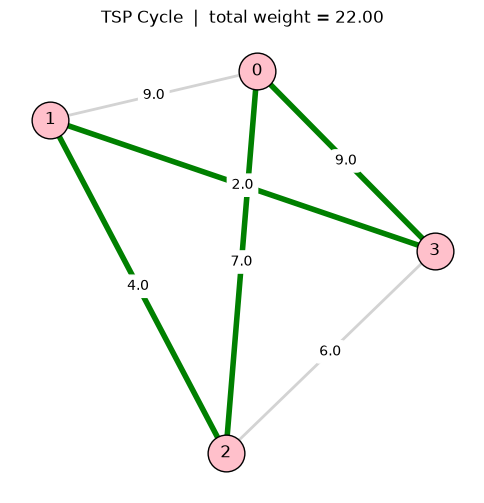

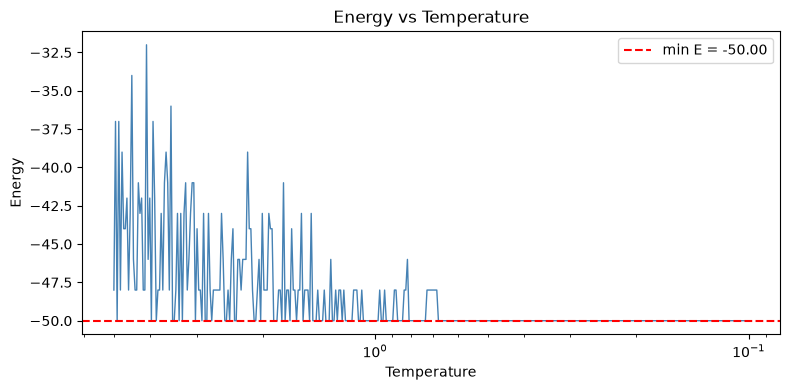

That gives us  sum of W=22
There is a difference of 0 between at 1

Annealing run 3

anneal
Validity of the run: True
Annealing TSP plot 3:


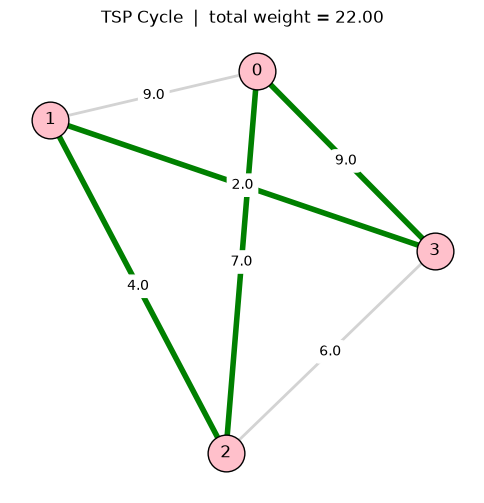

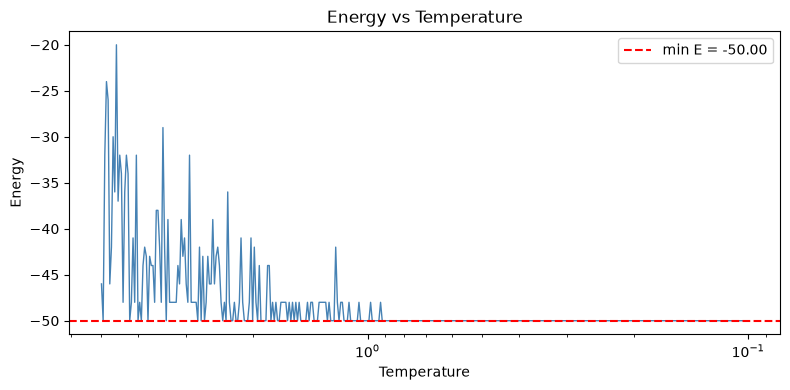

That gives us  sum of W=22
There is a difference of 0 between at 1


C:
 [1.5, 1.5, 1.5, 1.2, 1.2, 1.2, 1.1, 1.1, 1.1, 1, 1, 1]
differnce between annealing and bf for W sum
 [-2, 0, -2, 0, -2, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
G = nx.complete_graph(4)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.randint(1, 10)

W = nx.to_numpy_array(G, weight='weight')

Cs= [1.5,1.2,1.1,1]

C_vals = []
diffs = []

print("Testing this for different values of C")
print("C:",Cs, "\n")

for C in Cs:
    print("C=", C)
    #set up
    B = 1
    A = C * B * W.max()
    print("Then, A:", A)
    Q = build_tsp(G, A, B)
    #print("Q:\n",Q)
    
    # brute force 
    best_E, best_x = brute_force_qubo(Q)
    bf_cycle, bf_valid = read_tsp(G, best_x)
    print(f"Validity of the run: {bf_valid}")
    print(f"Brute force minimum energy: {best_E:.2f}")
    
    print("Brute force TSP plot:")
    bf_wsum=plot_tsp(G, bf_cycle, bf_valid)
    '''if bf_valid:
        N = len(bf_cycle)
        bf_wsum = sum(
            G[bf_cycle[i]][bf_cycle[(i + 1) % N]]["weight"]
            for i in range(N)
        )
        print("sum W :", bf_wsum)'''
    print("sum W :", bf_wsum)
    
    #annealing
    print("Anneal the same Q 3s to compare,")
    for i in range(3):
        print(f"\nAnnealing run {i+1}\n")
        temps, energies, anneal_x , cycle, valid = tsp_anneal(G,A,B,
                #T_start=max(10*C, 50),
                T_start=5,
                T_end=0.1,
                alpha=0.99,
                sweeps_per_T=2000)
        #cycle, valid = read_tsp(G, anneal_x) alread in tsp anneal
        print(f"Validity of the run: {valid}")
        print(f"Annealing TSP plot {i+1}:")
        sumW = plot_tsp(G, cycle, valid)
        plot_TvE(temps, energies)
        print(f"That gives us  sum of W={sumW}")
        diff= bf_wsum - sumW
        print(f"There is a difference of {diff} between at {C}")
        
        C_vals.append(C)
        diffs.append(diff)
        
    print("\n")
    
    print("C:\n", C_vals)
    print("differnce between annealing and bf for W sum\n",diffs)
    


Taking $0<B\max(W_{uv})<A$, 
Let $B=1$ $A=C\cdot B\cdot\max(W_{uv})$,

when $C\leq1.1$ we get the brute force and annealing to agree. Final test,


Testing this for different values of C
C: [1.5, 1.2, 1.1, 1] 

C= 1
Then, A: 9.0
Validity of the run: True
Brute force minimum energy: -56.00
Brute force TSP plot:


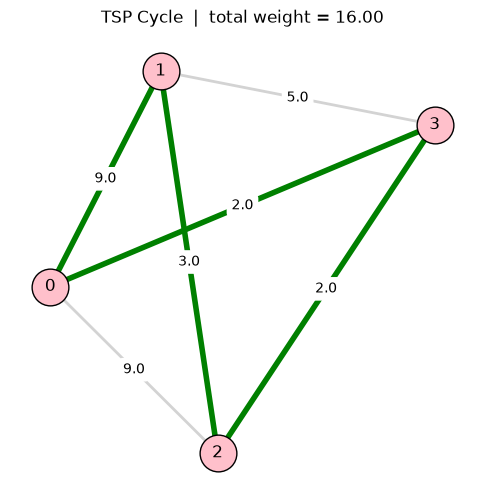

sum W : 16
Anneal the same Q 3s to compare,

Annealing run 1

anneal
Validity of the run: True
Annealing TSP plot 1:


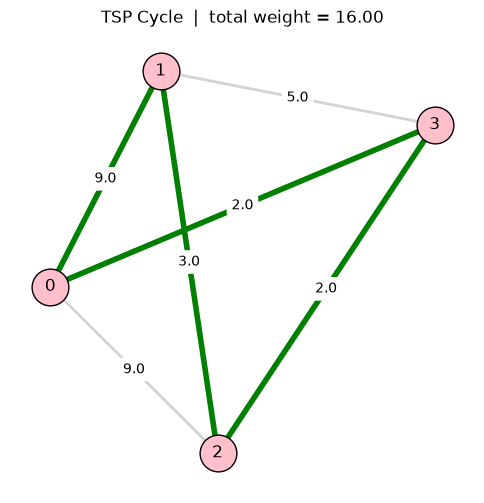

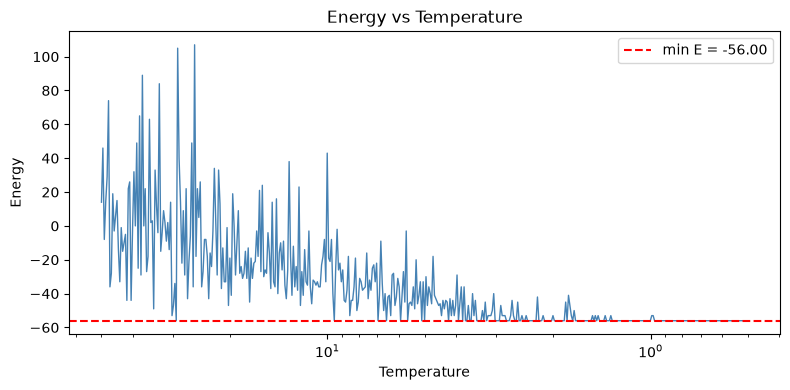

That gives us  sum of W=16
There is a difference of 0 between at C=1

Annealing run 2

anneal
Validity of the run: True
Annealing TSP plot 2:


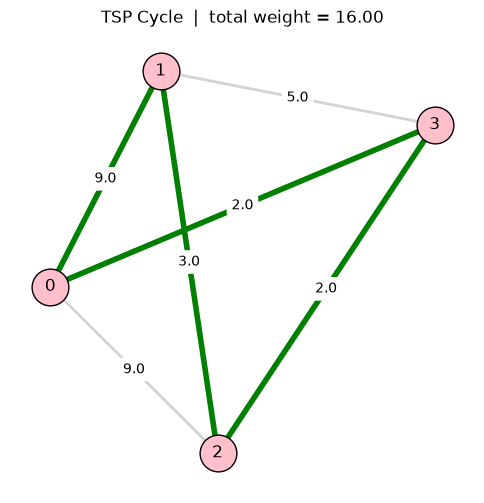

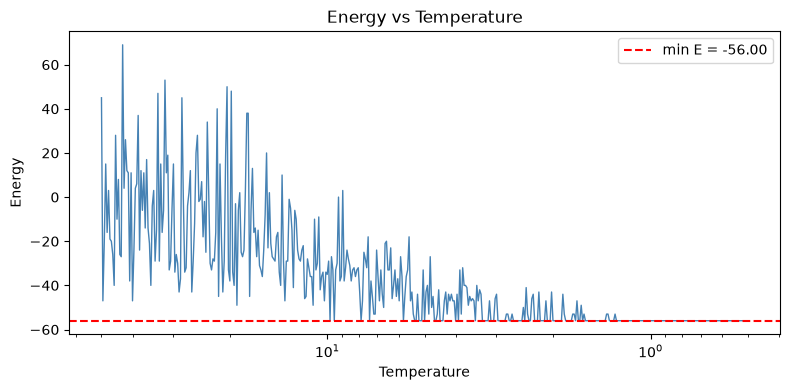

That gives us  sum of W=16
There is a difference of 0 between at C=1

Annealing run 3

anneal
Validity of the run: True
Annealing TSP plot 3:


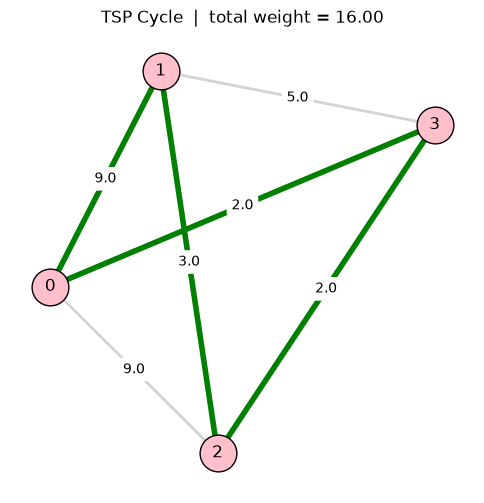

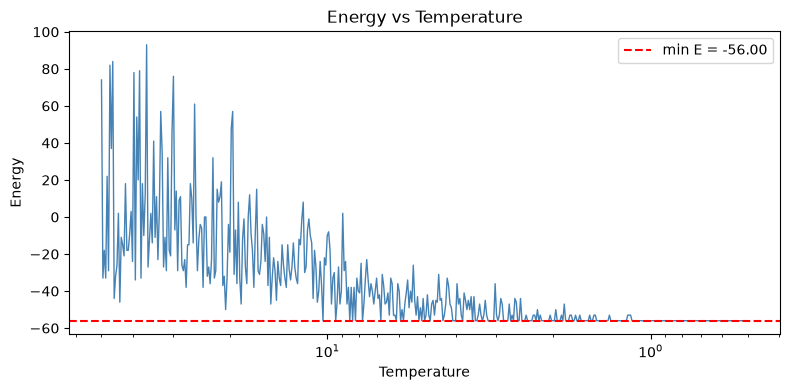

That gives us  sum of W=16
There is a difference of 0 between at C=1

Annealing run 4

anneal
Validity of the run: True
Annealing TSP plot 4:


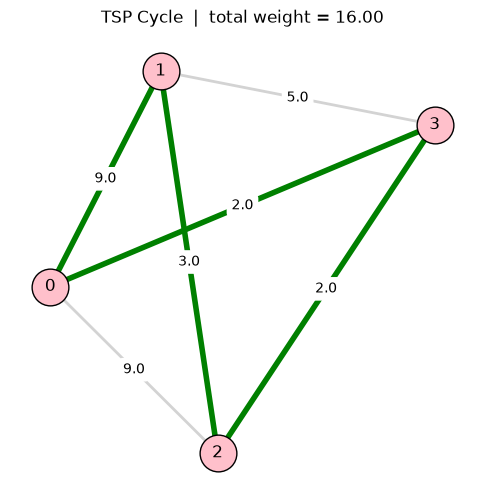

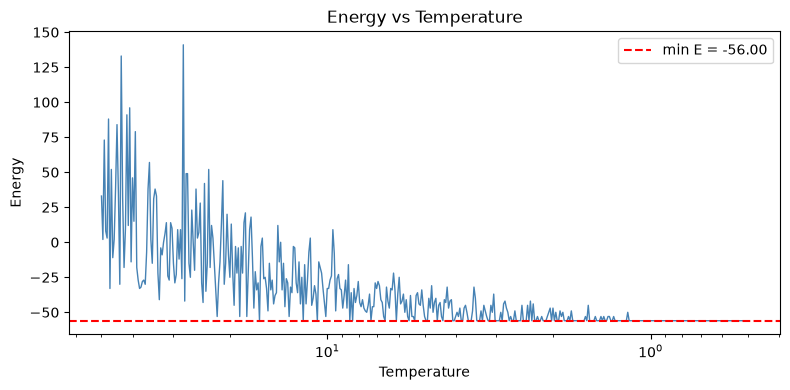

That gives us  sum of W=16
There is a difference of 0 between at C=1

Annealing run 5

anneal
Validity of the run: True
Annealing TSP plot 5:


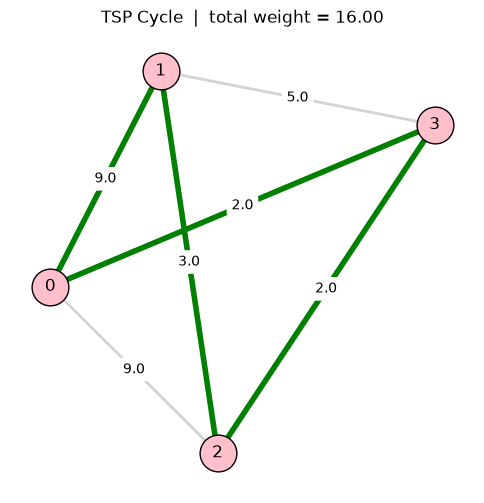

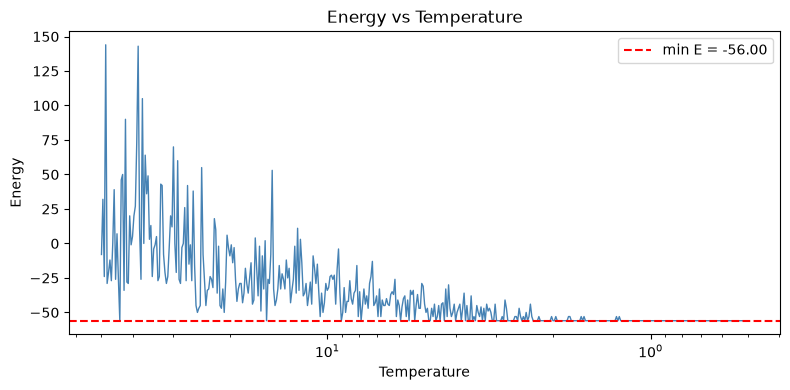

That gives us  sum of W=16
There is a difference of 0 between at C=1


differnce between annealing and bf for W sum
 [0, 0, 0, 0, 0]


In [ ]:
G = nx.complete_graph(4)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.randint(1, 10)

W = nx.to_numpy_array(G, weight='weight')

C=1


C_vals = []
diffs = []

print("Testing this for different values of C")
print("C:",Cs, "\n")

for _ in range(1):
    print("C=", C)
    #set up
    B = 1
    A = C * B * W.max()
    print("Then, A:", A)
    Q = build_tsp(G, A, B)
    #print("Q:\n",Q)
    
    # brute force 
    best_E, best_x = brute_force_qubo(Q)
    bf_cycle, bf_valid = read_tsp(G, best_x)
    print(f"Validity of the run: {bf_valid}")
    print(f"Brute force minimum energy: {best_E:.2f}")
    
    print("Brute force TSP plot:")
    bf_wsum=plot_tsp(G, bf_cycle, bf_valid)
    '''if bf_valid:
        N = len(bf_cycle)
        bf_wsum = sum(
            G[bf_cycle[i]][bf_cycle[(i + 1) % N]]["weight"]
            for i in range(N)
        )
        print("sum W :", bf_wsum)'''
    print("sum W :", bf_wsum)
    
    #annealing
    print("Anneal the same Q 3s to compare,")
    for i in range(5):
        print(f"\nAnnealing run {i+1}\n")
        temps, energies, anneal_x , cycle, valid = tsp_anneal(G,A,B,
                #T_start=max(10*C, 50),
                T_start=50,
                T_end=0.5,
                alpha=0.99,
                sweeps_per_T=2000)
        #cycle, valid = read_tsp(G, anneal_x) alread in tsp anneal
        print(f"Validity of the run: {valid}")
        print(f"Annealing TSP plot {i+1}:")
        sumW = plot_tsp(G, cycle, valid)
        plot_TvE(temps, energies)
        print(f"That gives us  sum of W={sumW}")
        diff= bf_wsum - sumW
        print(f"There is a difference of {diff} between at C={C}")
        
        #C_vals.append(C)
        diffs.append(diff)
        
    print("\n")
    
    #print("C:\n", C_vals)
    print("differnce between annealing and bf for W sum\n",diffs)
    


## more realistic weights

Currently we have random integers as out weights instead we can define the distances beween nodes as our weights.

Define a function that randomises positions in a unit square,

In [ ]:
#redefining these with differnet save figs
def plot_TvE(temps, energies):
    plt.figure(figsize=(8, 4))
    plt.plot(temps, energies, color='steelblue', linewidth=1)
    plt.xlabel('Temperature')
    plt.ylabel('Energy')
    #plt.title(f'Energy vs Temperature')
    plt.xscale('log')
    plt.gca().invert_xaxis()  # time flows left to right: hot → cold
    plt.axhline(y=min(energies), color='red', linestyle='--', 
                label=f'min E = {min(energies):.2f}')
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(f"/home/cian/Documents/college/SURE/git/QUBO/example-problems/fig/dist/TvE-dist.pdf")

    plt.show()
    
def plot_tsp(G, cycle, valid, pos=None, Name=None):
    if not valid:
        print("Cannot plot: invalid TSP cycle.")
        return None

    if pos is None:
        pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(7, 7))

    # Draw all edges faintly
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="lightgrey",
        width=1.2,
        alpha=0.25
    )

    # Tour edges
    N = len(cycle)
    cycle_edges = [
        (cycle[i], cycle[(i + 1) % N])
        for i in range(N)
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cycle_edges,
        edge_color="forestgreen",
        width=4
    )

    # Nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color="#f7b6c2",
        node_size=700,
        edgecolors="black",
        linewidths=1.2
    )

    # All edge labels (light grey)
    weights = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels={e: f"{w:.2f}" for e, w in weights.items()},
        font_size=8,
        font_color="0.7",   # light grey
        rotate=False
    )

    # Redraw the tour labels in black
    tour_labels = {
        e: f"{G[e[0]][e[1]]['weight']:.2f}"
        for e in cycle_edges
    }


    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=tour_labels,
        font_size=10,
        font_color="black",
        rotate=False,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
    )

    total = sum(
        G[cycle[i]][cycle[(i + 1) % N]]["weight"]
        for i in range(N)
    )

    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    #plt.title(f"TSP Cycle |Type: {Name}| Total weight = {total:.2f}")
    
    plt.savefig(
        f"/home/cian/Documents/college/SURE/git/QUBO/example-problems/fig/dist/tsp-{Name}-dist-W-{total:.2f}.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return total



In [171]:
def distance_graph(N, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    pos = {i: (np.random.rand(), np.random.rand()) for i in range(N)}

    G = nx.complete_graph(N)

    for u, v in G.edges():
        dist = np.linalg.norm(
            np.array(pos[u]) - np.array(pos[v])
        )
        G[u][v]["weight"] = dist

    W = nx.to_numpy_array(G, weight="weight")
    
    return G, W, pos

Brute force TSP plot:


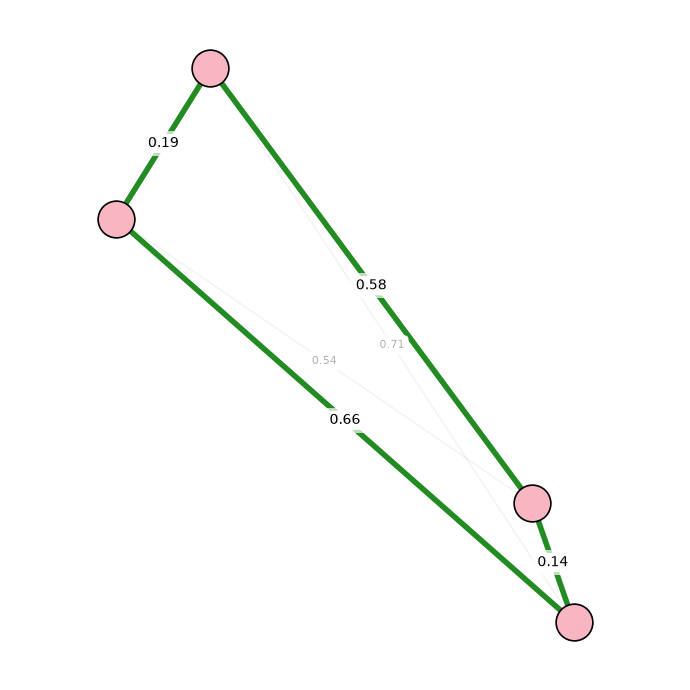

sum W : 1.5645936402877263

Annealing TSP plots 



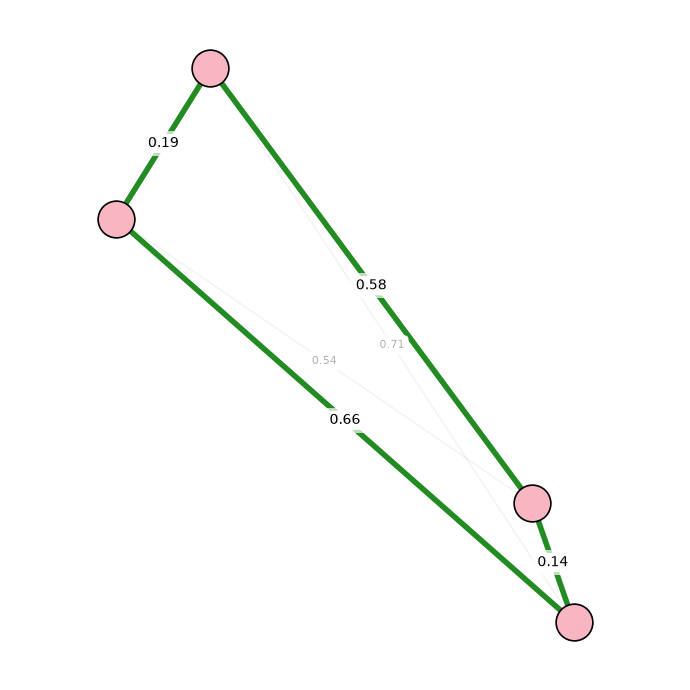

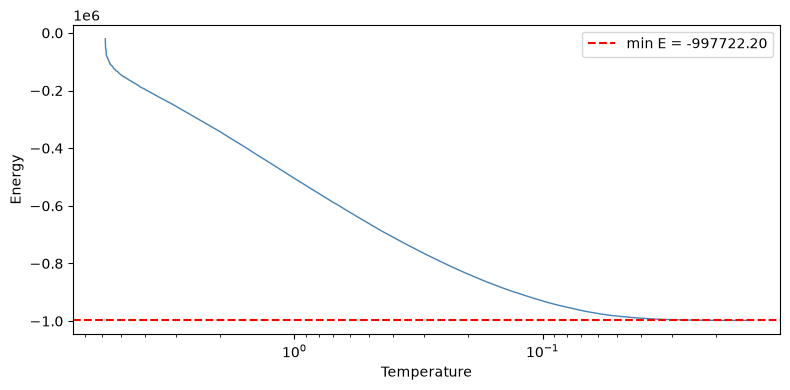

In [186]:
N = 4

G, W, pos = distance_graph(N)
#print(W)
B = 1
A = B * W.max()

Q = build_tsp(G, A, B)

print("Brute force TSP plot:")
best_E, best_x = brute_force_qubo(Q)
bf_cycle, bf_valid = read_tsp(G, best_x)
bf_wsum=plot_tsp(G, bf_cycle, bf_valid,pos, Name="Brute-force")
print("sum W :", bf_wsum)


print("\nAnnealing TSP plots \n")
temps, energies, anneal_x, cycle, valid = tsp_anneal(
    G, A, B,
    T_start=50,
    T_end=0.001,
    alpha=0.99,
    sweeps_per_T=2000
)

wsum=plot_tsp(G, cycle, valid, pos, Name="Annealing")
plot_TvE(temps, energies)

### testing C values (again)

this code will take a long time to run.

In [173]:
N=5

G, W, pos = distance_graph(N)

Cs = range(1, 11)
success_rate = []

attempts=10

for C in Cs:
    
    B = 1
    A = C * B * W.max()

    Q = build_tsp(G, A, B)

    best_E, best_x = brute_force_qubo(Q)
    bf_cycle, bf_valid = read_tsp(G, best_x)

    bf_weight = sum(
        G[bf_cycle[i]][bf_cycle[(i+1)%N]]["weight"]
        for i in range(N)
    )

    successes = 0

    for _ in range(attempts):

        _, _, _, cycle, valid = tsp_anneal(
            G, A, B,
            T_start=25,
            T_end=0.1,
            alpha=0.99,
            sweeps_per_T=1000
        )

        if not valid:
            continue

        w = sum(
            G[cycle[i]][cycle[(i+1)%N]]["weight"]
            for i in range(N)
        )

        if np.isclose(w, bf_weight):
            successes += 1

    success_rate.append(successes / attempts)
    
print(success_rate)
plt.plot(Cs, success_rate)
plt.show()

KeyboardInterrupt: 

## OpenStreetMaps
Lets try this traveling salesperson QUBO annealing on a real map, using OpenStreetMap and `osmnx`

### Dublin
Starting with dublin, download the dublin map and then map some points.


In [56]:
#car
# Unprojected in (lat,lon), must compute distances on a sphere
dublin_drive = ox.graph_from_place("Dublin, Ireland", network_type="drive")

# Projected (UTM metres), coordinates are converted to a flat 2D plane in metres
dublin_proj_drive = ox.project_graph(dublin_drive)


#walking
# Unprojected 
dublin_walk = ox.graph_from_place("Dublin, Ireland", network_type="walk")

# Projected
dublin_proj_walk = ox.project_graph(dublin_walk)


In [57]:
'''
# hard codded coords
points = {
    "Spire":           (53.3498, -6.2603),
    "Trinity":         (53.3459, -6.2574),
    "St Stephens":     (53.3382, -6.2591),
    "Guinness":        (53.3418, -6.2868),
    "Phoenix Park":    (53.3558, -6.3296),
    "Croke Park":      (53.3606, -6.2510),
    "Aviva":           (53.3352, -6.2284),
}
'''

'\n# hard codded coords\npoints = {\n    "Spire":           (53.3498, -6.2603),\n    "Trinity":         (53.3459, -6.2574),\n    "St Stephens":     (53.3382, -6.2591),\n    "Guinness":        (53.3418, -6.2868),\n    "Phoenix Park":    (53.3558, -6.3296),\n    "Croke Park":      (53.3606, -6.2510),\n    "Aviva":           (53.3352, -6.2284),\n}\n'

Rather use *eircodes* than positions,

***Doesnt work Nominatim is bad with eircodes***

In [58]:
### Doesnt work Nominatim is bad with eircodes

geolocator = Nominatim(user_agent="tsp_eircode")

def eircode_to_coords(eircode):
    location = geolocator.geocode(eircode + ", Ireland")
    if location:
        return (location.latitude, location.longitude)
    else:
        print(f"Could not find {eircode}")
        return None
    
eircodes = {
    "My Gaff":      "D08 X524",
    "Spire":        "D01 F5P2",
    "Trinity":      "D02 PN40",
    "St Stephens Green":  "D02 NY46",
    "Guinness Storehouse":     "D08 VF8H",
    "Phoenix Park": "D08 X9HK",
    "Croke Park":   "D03 P6K7",
    "Aviva":        "D04 E3W7",
}

points = {name: eircode_to_coords(code) 
          for name, code in eircodes.items()}

print(points)

{'My Gaff': (52.0600343, -0.347478), 'Spire': (53.3493585, -6.2605762), 'Trinity': (52.0600343, -0.347478), 'St Stephens Green': (52.0600343, -0.347478), 'Guinness Storehouse': (52.0600343, -0.347478), 'Phoenix Park': (52.0600343, -0.347478), 'Croke Park': (52.0600343, -0.347478), 'Aviva': (52.0600343, -0.347478)}


#### First attempt of a Dublin TSP

Instead lets look up addresses to get our points in (latitude, longitude)

In [59]:
places = {
    "Lidl Viking": "Lidl, Aungier Street, Dublin 2",
    "Spire":                "Spire of Dublin, O'Connell Street, Dublin",
    "Trinity":              "Trinity College Dublin",
    "St Stephens Green":    "St Stephen's Green, Dublin",
    "Guinness Storehouse":  "Guinness Storehouse, Dublin 8",
    "Phoenix Park":         "Phoenix Park, Dublin",
    "Croke Park":           "Croke Park, Dublin 3",
    "Aviva":                "Aviva Stadium, Lansdowne Road, Dublin",
}

points = {}

geolocator = Nominatim(user_agent="tsp_eircode")
for name, place in places.items():
    location = geolocator.geocode(place)
    if location:
        points[name] = (location.latitude, location.longitude)
        print(f"{name}: ({location.latitude:.4f}, {location.longitude:.4f})")
    else:
        print(f"Could not find {name}")
    time.sleep(1)  # respect rate limit

print(points)

Lidl Viking: (53.3408, -6.2658)
Spire: (53.3498, -6.2603)
Trinity: (53.3437, -6.2544)
St Stephens Green: (53.3381, -6.2590)
Guinness Storehouse: (53.3419, -6.2867)
Phoenix Park: (53.3589, -6.3307)
Croke Park: (53.3604, -6.2510)
Aviva: (53.3352, -6.2282)
{'Lidl Viking': (53.3407888, -6.2657741), 'Spire': (53.3498019, -6.2602542), 'Trinity': (53.3437061, -6.2544278), 'St Stephens Green': (53.3380517, -6.2590232), 'Guinness Storehouse': (53.3419328, -6.2867297), 'Phoenix Park': (53.3589378, -6.3307105), 'Croke Park': (53.3603576, -6.2509812), 'Aviva': (53.3352254, -6.2281851)}


Snap to nodes on the dublin projected map

In [62]:
# get the projection osmnx used
crs = dublin_proj_drive.graph['crs']
transformer = pyproj.Transformer.from_crs("EPSG:4326", crs, always_xy=True)

# snap nodes using projected coordinates
road_nodes = {}
for name, (lat, lon) in points.items():
    x, y = transformer.transform(lon, lat)  # convert to UTM
    road_nodes[name] = ox.nearest_nodes(dublin_proj_drive, x, y)
    time.sleep(0.1)

print("Road nodes:", road_nodes)

Road nodes: {'Lidl Viking': 1448442, 'Spire': 5300250111, 'Trinity': 1497243682, 'St Stephens Green': 8914657804, 'Guinness Storehouse': 224035944, 'Phoenix Park': 11853415, 'Croke Park': 1540661083, 'Aviva': 2366161690}


convert (lat, lon) into (x,y)

In [ ]:
for name, (lat, lon) in points.items():
    x, y = transformer.transform(lon, lat)
    node = road_nodes[name]
    print(f"{name}: lat={lat}, lon={lon} to x={x:.0f}, y={y:.0f} to node={node}\n")


print("test one pair") 
u = road_nodes["Spire"]
v = road_nodes["Trinity"]
dist = nx.shortest_path_length(dublin_proj, u, v, weight='length')
print(f"Spire to Trinity: {dist/1000:.2f} km")


Lidl Viking: lat=53.3407888, lon=-6.2657741 to x=682027, y=5913667 to node=1448442

Spire: lat=53.3498019, lon=-6.2602542 to x=682356, y=5914683 to node=5300250111

Trinity: lat=53.3437061, lon=-6.2544278 to x=682770, y=5914020 to node=1497243682

St Stephens Green: lat=53.3380517, lon=-6.2590232 to x=682488, y=5913380 to node=8914657804

Guinness Storehouse: lat=53.3419328, lon=-6.2867297 to x=680627, y=5913741 to node=224035944

Phoenix Park: lat=53.3589378, lon=-6.3307105 to x=677629, y=5915522 to node=11853415

Croke Park: lat=53.3603576, lon=-6.2509812 to x=682928, y=5915881 to node=1540661083

Aviva: lat=53.3352254, lon=-6.2281851 to x=684553, y=5913145 to node=2366161690

test one pair
Spire to Trinity: 0.94 km


construct the weight matrix

In [ ]:
names = list(points.keys())
n = len(names)

W = np.zeros((n, n))

for i, j in itertools.combinations(range(n), 2):
    u = road_nodes[names[i]]
    v = road_nodes[names[j]]
    dist = nx.shortest_path_length(dublin_proj, u, v, weight='length')
    W[i, j] = dist
    W[j, i] = dist
    print(f"{names[i]} to {names[j]}: {dist/1000:.2f} km")

print("\nDistance matrix (km):")
print((W/1000).round(2))

Lidl Viking to Spire: 2.51 km
Lidl Viking to Trinity: 1.39 km
Lidl Viking to St Stephens Green: 0.78 km
Lidl Viking to Guinness Storehouse: 1.97 km


Lidl Viking to Phoenix Park: 5.00 km
Lidl Viking to Croke Park: 3.55 km
Lidl Viking to Aviva: 3.25 km
Spire to Trinity: 0.94 km
Spire to St Stephens Green: 2.30 km
Spire to Guinness Storehouse: 3.01 km
Spire to Phoenix Park: 5.77 km
Spire to Croke Park: 2.63 km
Spire to Aviva: 3.07 km
Trinity to St Stephens Green: 2.01 km
Trinity to Guinness Storehouse: 2.72 km
Trinity to Phoenix Park: 5.52 km
Trinity to Croke Park: 2.64 km
Trinity to Aviva: 2.58 km
St Stephens Green to Guinness Storehouse: 2.25 km
St Stephens Green to Phoenix Park: 5.66 km
St Stephens Green to Croke Park: 4.10 km
St Stephens Green to Aviva: 2.60 km
Guinness Storehouse to Phoenix Park: 4.44 km
Guinness Storehouse to Croke Park: 4.38 km
Guinness Storehouse to Aviva: 4.60 km
Phoenix Park to Croke Park: 6.19 km
Phoenix Park to Aviva: 7.78 km
Croke Park to Aviva: 4.15 km

Distance matrix (km):
[[0.   2.51 1.39 0.78 1.97 5.   3.55 3.25]
 [2.51 0.   0.94 2.3  3.01 5.77 2.63 3.07]
 [1.39 0.94 0.   2.01 2.72 5.52 2.64 2.58]
 [

In [ ]:
G_dub = nx.complete_graph(n)

# normalise distances to [0, 1]
W_norm = W / W.max()


for i,j in itertools.combinations(range(n),2):
    G_dub[i][j]['weight'] = W_norm[i,j]
    
'''nx.relabel_nodes(G_dub, {i: names[i] for i in range(n)}, copy=False)

# build graph with normalised weights
for i, j in itertools.combinations(range(n), 2):
    G_dub[names[i]][names[j]]['weight'] = W_norm[i][j]
'''
print(G_dub)
#print(G_dub.nodes())
#print(G_dub.edges(data=True))

B = 1.0
A =1* B * W_norm.max()

#print(f"Max distance: {W.max()/1000:.2f} km")
print(f"A = {A:.1f},  B = {B}")

Q = build_tsp(G_dub, A, B)
Q = (Q + Q.T) / 2

print(f"Q shape: {Q.shape}")
print(Q)


Graph with 8 nodes and 28 edges
A = 1.0,  B = 1.0
Q shape: (64, 64)
[[-2.          1.          1.         ...  0.          0.
   0.20895544]
 [ 1.         -2.          1.         ...  0.          0.
   0.        ]
 [ 1.          1.         -2.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... -2.          1.
   1.        ]
 [ 0.          0.          0.         ...  1.         -2.
   1.        ]
 [ 0.20895544  0.          0.         ...  1.          1.
  -2.        ]]


In [ ]:
N = G_dub.number_of_nodes()

x_test = np.zeros(N*N)

for i in range(N):
    x_test[idx(i,i,N)] = 1

E_valid = x_test @ Q @ x_test

print("Energy:", E_valid)
read_tsp(G_dub, x_test, verbose=True)

Energy: -12.689882468599235
Cycle: [0, 1, 2, 3, 4, 5, 6, 7]
Missing edges: []
Total weight: 3.31
Valid: True


([0, 1, 2, 3, 4, 5, 6, 7], True)

Validity of the run: True
Annealing TSP plot:


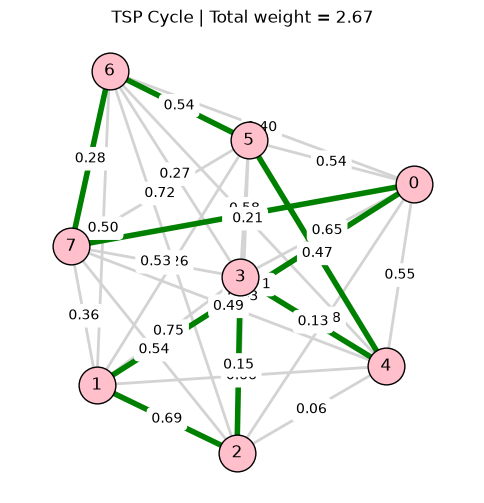

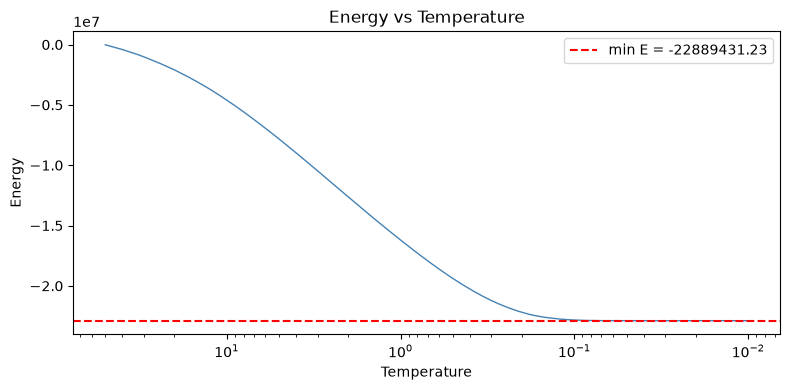

In [ ]:
temps, energies, anneal_x, cycle, valid = tsp_anneal(G_dub, A, B, 
    T_start=50.0,
    T_end=0.01,
    alpha=0.99,
    sweeps_per_T=2000)

print(f"Validity of the run: {valid}")
print(f"Annealing TSP plot:")
sumW = plot_tsp(G, cycle, valid)
plot_TvE(temps, energies)


Now that we see that our Dublin TSP works, lets make it into a function.

### Dublin TSP

In [63]:
def plot_tsp_osm(G, cycle, valid, dublin_proj, road_nodes, points, names):
    if not valid:
        print("Cannot plot: invalid TSP cycle.")
        return

    # plot the road network
    fig, ax = ox.plot_graph(
        dublin_proj,
        show=False,
        close=False,
        node_size=0,
        edge_color='grey',
        edge_linewidth=0.3,
        edge_alpha=0.5,
        bgcolor='white'
    )

    # get projected coordinates for each location
    node_data = dict(dublin_proj.nodes(data=True))
    proj_coords = {
        name: (
            node_data[road_nodes[name]]["x"],
            node_data[road_nodes[name]]["y"]
        )
        for name in names
    }

    # store all path coordinates for automatic zoom
    path_xs = []
    path_ys = []

    # draw actual road paths
    for i in range(len(cycle)):
        u = cycle[i]
        v = cycle[(i + 1) % len(cycle)]

        start = road_nodes[names[u]]
        end = road_nodes[names[v]]

        path = nx.shortest_path(
            dublin_proj,
            start,
            end,
            weight="length"
        )

        xs = [node_data[n]["x"] for n in path]
        ys = [node_data[n]["y"] for n in path]

        path_xs.extend(xs)
        path_ys.extend(ys)

        ax.plot(
            xs,
            ys,
            "g-",
            linewidth=2.5,
            zorder=3
        )

    # draw nodes
    for name in names:
        x, y = proj_coords[name]
        ax.scatter(x, y, c="red", s=100, zorder=5)
        ax.annotate(
            name,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
            zorder=6
        )

    # total weight
    total = sum(
        G[cycle[i]][cycle[(i + 1) % len(cycle)]]["weight"]
        for i in range(len(cycle))
    )

    ax.set_title(f"TSP Cycle on Dublin ")#| Total = {total * W.max() / 1000:.2f} km")

    # Automatically zoom to the plotted route
    min_x, max_x = min(path_xs), max(path_xs)
    min_y, max_y = min(path_ys), max(path_ys)

    width = max_x - min_x
    height = max_y - min_y

    # 10% margin around the route
    margin = max(width, height) * 0.10
    margin = max(margin, 100)  # minimum 100 m

    ax.set_xlim(min_x - margin, max_x + margin)
    ax.set_ylim(min_y - margin, max_y + margin)
    plt.savefig("/home/cian/Documents/college/SURE/git/QUBO/example-problems/fig/dublin-tsp.pdf")
    plt.show()
    

In [64]:
places = {
    "Lidl Viking": "Lidl, Aungier Street, Dublin 2",
    "Spire":                "Spire of Dublin, O'Connell Street, Dublin",
    "Trinity":              "Trinity College Dublin",
    "St Stephens Green":    "St Stephen's Green, Dublin",
    "Guinness Storehouse":  "Guinness Storehouse, Dublin 8",
    "Phoenix Park":         "Phoenix Park, Dublin",
    "Croke Park":           "Croke Park, Dublin 3",
    "Aviva":                "Aviva Stadium, Lansdowne Road, Dublin",
}


def run_tsp_OSM(places, drive):
    if drive == True:
        dublin_proj=dublin_proj_drive
    
    if drive == False:
        dublin_proj=dublin_proj_walk
    
    else:
        raise ValueError(
            "No method of transport, drive==True or drive==False"
        )

    geolocator = Nominatim(user_agent="tsp_eircode") 
    
    points = {}
    
    for name, place in places.items():

        # Already has coordinates
        if isinstance(place, tuple):
            points[name] = place

        # Need to geocode an address
        else:
            location = geolocator.geocode(place)

            if location:
                points[name] = (location.latitude, location.longitude)
            else:
                print(f"Could not find {name}")

            time.sleep(1)

    if len(points) != len(places):
        raise ValueError(f"Only found {len(points)}/{len(places)} locations")
    
    # get the projection osmnx used
    crs = dublin_proj.graph['crs']
    transformer = pyproj.Transformer.from_crs("EPSG:4326", crs, always_xy=True)

    # snap nodes using projected coordinates
    road_nodes = {}
    for name, (lat, lon) in points.items():
        x, y = transformer.transform(lon, lat)  # convert to UTM
        road_nodes[name] = ox.nearest_nodes(dublin_proj, x, y)
        time.sleep(0.1)

    print("Road nodes:", road_nodes)
    
    # (lat, lon) to (x,y)
    for name, (lat, lon) in points.items():
        x, y = transformer.transform(lon, lat)
        node = road_nodes[name]
        print(f"{name}: lat={lat}, lon={lon} to x={x:.0f}, y={y:.0f} to node={node}\n")
        
    names = list(points.keys())
    
    #build the weight matrix W
    
    n = len(names)

    W = np.zeros((n, n))

    for i, j in itertools.combinations(range(n), 2):
        u = road_nodes[names[i]]
        v = road_nodes[names[j]]
        dist = nx.shortest_path_length(dublin_proj, u, v, weight='length')
        W[i, j] = dist
        W[j, i] = dist
        #print(f"{names[i]} to {names[j]}: {dist/1000:.2f} km")

    G_dub = nx.complete_graph(n)

    # normalise distances to [0, 1]
    W_norm = W / W.max()


    for i,j in itertools.combinations(range(n),2):
        G_dub[i][j]['weight'] = W_norm[i,j]

    B = 1.0
    A =1* B * W_norm.max()

    print(f"A = {A:.1f},  B = {B}")

    Q = build_tsp(G_dub, A, B)
    Q = (Q + Q.T) / 2

    print("Lets anneal")
    temps, energies, anneal_x, cycle, valid = tsp_anneal(G_dub, A, B, 
        T_start=50.0,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=2000)

    print(f"Validity of the run: {valid}")
    print(f"Annealing TSP plot:")
    sumW = plot_tsp(G_dub, cycle, valid)
    plot_TvE(temps, energies)
    plot_tsp_osm(G_dub, cycle, valid, dublin_proj, road_nodes, points, names)
#run_tsp_OSM(places, False)

We can scrape tags of the Open Street Maps instead of inputing our cords or adressess

In [65]:
# Query pubs within 2 km of Lidl
pubs = ox.features_from_address(
    "Lidl, Aungier Street, Dublin 2",
    tags={"amenity": "pub"},
    dist=300   # metres
)

print(pubs)


                                                             geometry  \
element id                                                              
node    367411336                           POINT (-6.26461 53.34199)   
        503224346                           POINT (-6.26543 53.34059)   
        583411333                           POINT (-6.26416 53.34189)   
        583412899                           POINT (-6.27005 53.34312)   
        768231201                           POINT (-6.26387 53.34312)   
        768231204                            POINT (-6.2617 53.34009)   
        768231205                            POINT (-6.26429 53.3412)   
        6782589728                          POINT (-6.26133 53.33952)   
way     229316784   POLYGON ((-6.2628 53.3423, -6.26283 53.34224, ...   
        230357177   POLYGON ((-6.26332 53.34088, -6.26327 53.34095...   
        230567953   POLYGON ((-6.26238 53.34104, -6.26253 53.34108...   
        230567954   POLYGON ((-6.26169 53.34094, -6

In [66]:
pub_places = {}

for i, (_, row) in enumerate(pubs.iterrows()):
    name = row.get("name", f"Pub_{i}")

    pt = row.geometry.representative_point()

    pub_places[name] = (pt.y, pt.x)

Road nodes: {'Hogan’s Bar': 26165156, 'Thomas Moore Inn': 1448442, 'The Secret Bar / The Bar With No Name': 13133056456, 'The Lord Edward': 6224327370, 'The Exchequer': 26165224, 'Sinnott’s': 4122981470, 'Caribou': 26165710, 'The Well': 2389814115, "J. Grogan's": 32236559, "Peter's Pub": 32237862, 'Bar Rua': 32235616, 'Sheehan’s': 135109491, 'The International Bar': 26165233, 'The Hairy Lemon': 12015832606, 'The Rag Trader': 10743755510, 'The Old Stand': 26165233, 'The Swan': 135109553, 'John O’Dywer’s': 2384200130, 'The Long Hall': 26165126, 'Nolita': 5546325170}
Hogan’s Bar: lat=53.3419933, lon=-6.2646102 to x=682099, y=5913804 to node=26165156

Thomas Moore Inn: lat=53.3405863, lon=-6.2654253 to x=682051, y=5913645 to node=1448442

The Secret Bar / The Bar With No Name: lat=53.3418854, lon=-6.2641559 to x=682130, y=5913793 to node=13133056456

The Lord Edward: lat=53.3431186, lon=-6.2700507 to x=681732, y=5913915 to node=6224327370

The Exchequer: lat=53.3431203, lon=-6.263866 to x=

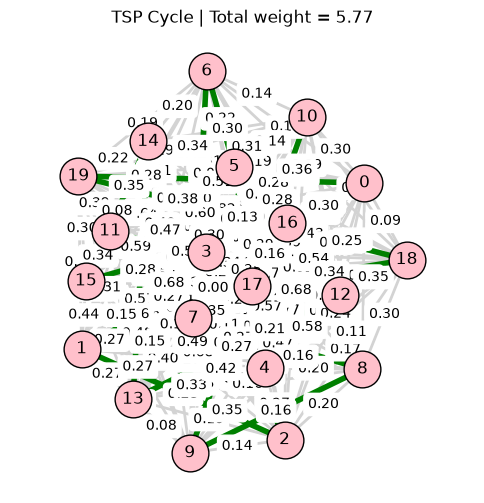

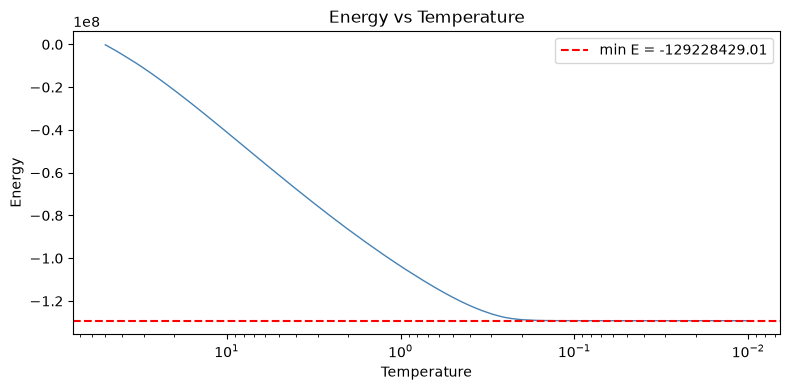

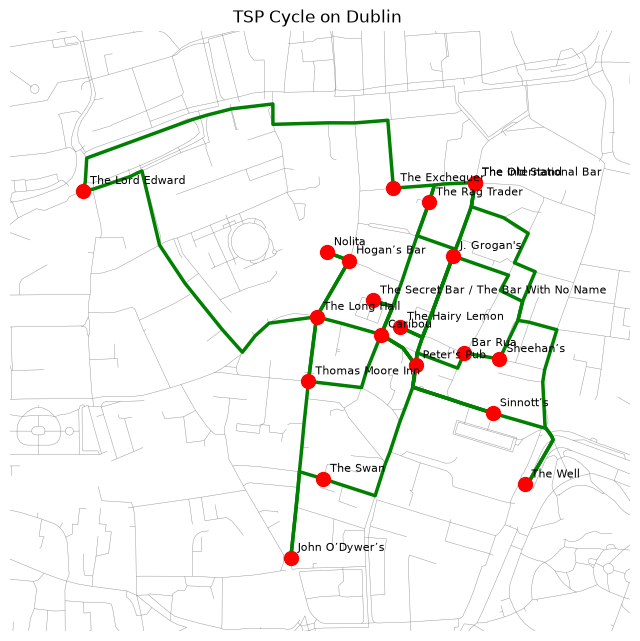

In [67]:
run_tsp_OSM(pub_places,False)